#  AI-Driven Triage System for Emergency Rooms
### Dataset: MIMIC-IV (ED + Hosp + ICU modules)
### Classification:  Critical |  Urgent |  Stable

---

**Project Architecture:**
- **Label source:** `ed/triage.csv` → `acuity` column (ESI 1-5) → mapped to 3 levels
- **Input features:** ER arrival vitals + demographics + comorbidities + clinical scores
- **Models:** Random Forest + XGBoost + LightGBM (compare all 3)
- **Explainability:** SHAP values

---


##  STEP 0 — Dataset Download Instructions

### Files Required (download from PhysioNet before running this notebook)

You need **2 datasets** from PhysioNet. Both require free registration + CITI training.

---

### Dataset 1: MIMIC-IV-ED
 Link: https://physionet.org/content/mimic-iv-ed/

Download these 4 files:
| File | Size | Path after download |
|------|------|---------------------|
| `triage.csv.gz` | ~15 MB | `mimic-iv-ed/ed/triage.csv.gz` |
| `edstays.csv.gz` | ~15 MB | `mimic-iv-ed/ed/edstays.csv.gz` |
| `vitalsign.csv.gz` | ~60 MB | `mimic-iv-ed/ed/vitalsign.csv.gz` |
| `diagnosis.csv.gz` | ~20 MB | `mimic-iv-ed/ed/diagnosis.csv.gz` |

---

### Dataset 2: MIMIC-IV (Hosp + ICU)
 Link: https://physionet.org/content/mimiciv/

Download these 5 files:
| File | Size | Path after download |
|------|------|---------------------|
| `patients.csv.gz` | ~3 MB | `mimic-iv/hosp/patients.csv.gz` |
| `admissions.csv.gz` | ~20 MB | `mimic-iv/hosp/admissions.csv.gz` |
| `diagnoses_icd.csv.gz` | ~30 MB | `mimic-iv/hosp/diagnoses_icd.csv.gz` |
| `labevents.csv.gz` | ~6 GB ⚠️ | `mimic-iv/hosp/labevents.csv.gz` |
| `icustays.csv.gz` | ~2 MB | `mimic-iv/icu/icustays.csv.gz` |

> ⚠️ `labevents.csv.gz` is 6GB. We read it in **chunks** and filter only relevant labs. Takes 20-40 min once — then saved to Drive permanently.

---

### How to Upload to Google Drive

1. Create a folder in Google Drive: `MyDrive/mimic4/`
2. Upload all 9 files into that folder
3. Keep the `.gz` format — **do NOT extract** them. Pandas reads `.gz` directly.

Your Drive folder should look like:
```
MyDrive/
  mimic4/
    triage.csv.gz
    edstays.csv.gz
    vitalsign.csv.gz
    diagnosis.csv.gz
    patients.csv.gz
    admissions.csv.gz
    diagnoses_icd.csv.gz
    labevents.csv.gz
    icustays.csv.gz
```


##  STEP 1 — Setup: Install Libraries & Mount Drive

In [2]:
# Install required libraries (run once)
!pip install xgboost lightgbm shap imbalanced-learn --quiet

import warnings
warnings.filterwarnings('ignore')

#  Core 
import pandas as pd
import numpy as np
import os, gc

#  Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

#  ML 
from sklearn.ensemble          import RandomForestClassifier
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import LabelEncoder
from sklearn.metrics           import (classification_report, confusion_matrix,
                                       roc_auc_score, ConfusionMatrixDisplay)
from sklearn.impute            import SimpleImputer
from xgboost                   import XGBClassifier
from lightgbm                  import LGBMClassifier
from imblearn.over_sampling    import SMOTE
import shap

#  Drive 
# from google.colab import drive
# drive.mount('/content/drive')

DATA = '/Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/'
print("Drive mounted ✓")
print("\nChecking files...")

REQUIRED = [
    'triage.csv.gz', 'edstays.csv.gz', 'vitalsign.csv.gz', 'diagnosis.csv.gz',
    'patients.csv.gz', 'admissions.csv.gz', 'diagnoses_icd.csv.gz',
    'icustays.csv.gz'
]
for f in REQUIRED:
    path = DATA + f
    if os.path.exists(path):
        mb = os.path.getsize(path) / 1024**2
        print(f"   {f} ({mb:.1f} MB)")
    else:
        print(f"   MISSING: {f}")

# labevents check (large file - may be pre-filtered already)
LAB_RAW     = DATA + 'labevents.csv.gz'
LAB_FILTERED = DATA + 'labevents_filtered.csv'
if os.path.exists(LAB_FILTERED):
    mb = os.path.getsize(LAB_FILTERED) / 1024**2
    print(f"   labevents_filtered.csv ({mb:.1f} MB) ─ already processed!")
elif os.path.exists(LAB_RAW):
    mb = os.path.getsize(LAB_RAW) / 1024**2
    print(f"   labevents.csv.gz ({mb:.1f} MB) ─ will be filtered in Step 4")
else:
    print("   MISSING: labevents.csv.gz (or labevents_filtered.csv)")

print("Environment setup re-established.")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Drive mounted ✓

Checking files...
   triage.csv.gz (9.5 MB)
   edstays.csv.gz (9.8 MB)
   vitalsign.csv.gz (23.6 MB)
   diagnosis.csv.gz (12.0 MB)
   patients.csv.gz (2.7 MB)
   admissions.csv.gz (19.0 MB)
   diagnoses_icd.csv.gz (32.0 MB)
   icustays.csv.gz (3.2 MB)
   labevents.csv.gz (2472.8 MB) ─ will be filtered in Step 4
Environment setup re-established.


##  STEP 2 — Load ED Module (Primary Data Source)

These 4 tables come from `MIMIC-IV-ED`. They are small files and load quickly.
- `triage` → our label (acuity) + arrival vitals
- `edstays` → visit metadata (how patient arrived, what happened)
- `vitalsign` → time-series vitals during ER stay
- `diagnosis` → final ER diagnosis (ground truth validation)


In [3]:
import gc

#  Load ED tables 

print("Loading ED module...")

# Define dtypes for ED tables to reduce memory usage
ed_triage_dtypes = {
    'subject_id': 'int32', 'stay_id': 'int32', 'temperature': 'float32', 'heartrate': 'float32',
    'resprate': 'float32', 'o2sat': 'float32', 'sbp': 'float32', 'dbp': 'float32',
    'pain': 'float32'
    # acuity will be handled by converters explicitly
}
ed_edstays_dtypes = {
    'subject_id': 'int32', 'hadm_id': 'object', 'stay_id': 'int32',
    'gender': 'category', 'admission_type': 'category', 'arrival_transport': 'category'
}
ed_vitalsign_dtypes = {
    'subject_id': 'int32', 'stay_id': 'int32', 'charttime': 'object', # Will convert to datetime later
    'temperature': 'float32', 'heartrate': 'float32', 'resprate': 'float32', 'o2sat': 'float32',
    'sbp': 'float32', 'dbp': 'float32', 'pain': 'object', 'rhythm': 'category' # Changed 'pain' to object
}
ed_diagnosis_dtypes = {
    'subject_id': 'int32', 'hadm_id': 'int32', 'stay_id': 'int32', 'seq_num': 'int32',
    'icd_code': 'object', 'icd_version': 'int8'
}

# 1. TRIAGE ── our primary table (label + arrival vitals)
# Removed dtype=ed_triage_dtypes to resolve conflict with converters for 'acuity'
triage = pd.read_csv(DATA + 'triage.csv.gz', compression='gzip', low_memory=False, converters={'acuity': str})
print(f"  triage:    {triage.shape[0]:,} rows x {triage.shape[1]} cols")

# 2. EDSTAYS ── master visit table (anchor for all ED tables)
edstays = pd.read_csv(DATA + 'edstays.csv.gz', compression='gzip', low_memory=False, dtype=ed_edstays_dtypes)
print(f"  edstays:   {edstays.shape[0]:,} rows x {edstays.shape[1]} cols")

# 3. VITALSIGN ── repeated vitals during ER stay
vitalsign = pd.read_csv(DATA + 'vitalsign.csv.gz', compression='gzip', low_memory=False, dtype=ed_vitalsign_dtypes)
print(f"  vitalsign: {vitalsign.shape[0]:,} rows x {vitalsign.shape[1]} cols")

# 4. DIAGNOSIS ── final ER diagnosis
diagnosis = pd.read_csv(DATA + 'diagnosis.csv.gz', compression='gzip', low_memory=False, dtype=ed_diagnosis_dtypes)
print(f"  diagnosis: {diagnosis.shape[0]:,} rows x {diagnosis.shape[1]} cols")

print("\n ED module loaded!")
print("\nTriage table preview:")
print(triage.head(3).to_string())
print("\nAcuity distribution (ESI 1-5):")
print(triage['acuity'].value_counts().sort_index())
print(f"\nMissing acuity: {triage['acuity'].isna().sum():,} rows (will be dropped)")

gc.collect()

Loading ED module...
  triage:    425,087 rows x 11 cols
  edstays:   425,087 rows x 9 cols
  vitalsign: 1,564,610 rows x 11 cols
  diagnosis: 899,050 rows x 6 cols

 ED module loaded!

Triage table preview:
   subject_id   stay_id  temperature  heartrate  resprate  o2sat    sbp   dbp pain  acuity                  chiefcomplaint
0    10000032  32952584         97.8       87.0      14.0   97.0   71.0  43.0    7  2.0000                     Hypotension
1    10000032  33258284         98.4       70.0      16.0   97.0  106.0  63.0    0  3.0000  Abd pain, Abdominal distention
2    10000032  35968195         99.4      105.0      18.0   96.0  106.0  57.0   10  3.0000                 n/v/d, Abd pain

Acuity distribution (ESI 1-5):
acuity
            6987
1.0000     24019
2.0000    139411
3.0000    225066
4.0000     28504
5.0000      1100
Name: count, dtype: int64

Missing acuity: 0 rows (will be dropped)


2942

##  STEP 3 — Load Hosp Module (Demographics + Outcomes)

From the 22 Hosp tables, we load only 3:
- `patients` → age, gender (demographic features)
- `admissions` → hospital outcome (`hospital_expire_flag`)
- `diagnoses_icd` → comorbidity extraction (diabetes, hypertension, etc.)


In [4]:
#  Load Hosp tables 

print("Loading Hosp module...")

# Define dtypes for Hosp tables to reduce memory usage
hosp_patients_dtypes = {
    'subject_id': 'int32', 'gender': 'category', 'anchor_age': 'int32',
    'anchor_year': 'int32', 'anchor_year_group': 'category', 'dod': 'object' # will convert dod later
}
hosp_admissions_dtypes = {
    'subject_id': 'int32', 'hadm_id': 'int32', 'admittime': 'object', 'dischtime': 'object',
    'deathtime': 'object', 'admission_type': 'category', 'admit_provider_id': 'category',
    'admission_location': 'category', 'discharge_location': 'category', 'insurance': 'category',
    'language': 'category', 'marital_status': 'category', 'race': 'category',
    'edregtime': 'object', 'edouttime': 'object', 'hospital_expire_flag': 'int8'
}
hosp_diagnoses_icd_dtypes = {
    'subject_id': 'int32', 'hadm_id': 'int32', 'seq_num': 'int32',
    'icd_code': 'object', 'icd_version': 'int8'
}

# 1. PATIENTS ── demographics
patients = pd.read_csv(DATA + 'patients.csv.gz', compression='gzip', low_memory=False, dtype=hosp_patients_dtypes)
print(f"  patients:       {patients.shape[0]:,} rows × {patients.shape[1]} cols")

# 2. ADMISSIONS ── outcomes
admissions = pd.read_csv(DATA + 'admissions.csv.gz', compression='gzip', low_memory=False, dtype=hosp_admissions_dtypes)
print(f"  admissions:     {admissions.shape[0]:,} rows × {admissions.shape[1]} cols")

# 3. DIAGNOSES_ICD ── comorbidities
diagnoses_icd = pd.read_csv(DATA + 'diagnoses_icd.csv.gz', compression='gzip', low_memory=False, dtype=hosp_diagnoses_icd_dtypes)
print(f"  diagnoses_icd:  {diagnoses_icd.shape[0]:,} rows × {diagnoses_icd.shape[1]} cols")

print("\n Hosp module loaded!")
print("\nPatients columns:", list(patients.columns))
print("Admissions columns:", list(admissions.columns))
print("\nGender distribution:")
print(patients['gender'].value_counts())
print("\nAge stats:")
print(patients['anchor_age'].describe())

gc.collect()

Loading Hosp module...
  patients:       364,627 rows × 6 cols
  admissions:     546,028 rows × 16 cols
  diagnoses_icd:  6,364,488 rows × 5 cols

 Hosp module loaded!

Patients columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
Admissions columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']

Gender distribution:
gender
F    191984
M    172643
Name: count, dtype: int64

Age stats:
count    364627.000000
mean         48.875097
std          20.943316
min          18.000000
25%          29.000000
50%          48.000000
75%          65.000000
max          91.000000
Name: anchor_age, dtype: float64


0

## 📂 STEP 4 — Load Lab Events (Chunked — runs once, then saved)

`labevents.csv.gz` is 6GB with 100M+ rows. We filter it down to 6 key lab tests:

| Lab Test | itemid | Why Important |
|----------|--------|---------------|
| Troponin-T | 51003 | Heart attack marker |
| Troponin-I | 51002 | Heart attack marker |
| Lactate | 50813 | Sepsis severity |
| WBC | 51301 | Infection / inflammation |
| Creatinine | 50912 | Kidney failure |
| Glucose | 50931 | Diabetic emergency |

> ⏱️ This cell takes **20-40 minutes** on first run. After that, it loads from saved CSV in seconds.


In [5]:
DATA = '/Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/'

In [6]:
#  Load/Filter labevents 

# Key lab item IDs we care about for triage
KEY_LABS = {
    #  CARDIAC 
    51003: 'troponin_t',
    51002: 'troponin_i',
    50867: 'bnp',              # Heart failure
    52353: 'nt_probnp',        # Heart failure (alt)
    50827: 'd_dimer',          # PE / DVT / aortic dissection

    #  SEPSIS / INFECTION 
    50813: 'lactate',
    51301: 'wbc',
    51144: 'bands',            # Neutrophil bands (early sepsis)

    #  METABOLIC / ELECTROLYTES 
    50931: 'glucose',
    50983: 'sodium',           # Hyponatremia → seizure
    50971: 'potassium',        # Hyperkalemia → cardiac arrest
    50882: 'bicarbonate',      # Acidosis marker

    #  BLOOD GAS 
    50820: 'ph',               # Acidosis / alkalosis
    50818: 'pco2',             # Respiratory failure

    #  RENAL / HAEMATOLOGY 
    50912: 'creatinine',
    51222: 'hemoglobin',
    51265: 'platelets',
    51006: 'bun',              #  BUN:Creatinine ratio (dehydration/GI bleed)

    #  LIVER / GI 
    50956: 'lipase',           #  Acute pancreatitis
    50861: 'alt',              # Liver damage / overdose
    50878: 'ast',              #  Liver damage
    50884: 'bilirubin_total',  #  Biliary obstruction

    #  COAGULATION 
    51237: 'inr',              #  Warfarin / coagulopathy
}
KEY_IDS = set(KEY_LABS.keys())

LAB_FILTERED = DATA + 'labevents_filtered.csv'

# Define dtypes for filtered labs to reduce memory usage
filtered_lab_dtypes = {
    'subject_id': 'Int32', # Changed to nullable integer
    'hadm_id': 'Int32',     # Changed to nullable integer
    'itemid': 'Int32',
    'valuenum': 'float32', 'charttime': 'object' # will convert charttime later
}

if os.path.exists(LAB_FILTERED):
    print(f" Filtered lab file found ─ loading directly...")
    labs_raw = pd.read_csv(LAB_FILTERED, low_memory=False, dtype=filtered_lab_dtypes)
    print(f"   Shape: {labs_raw.shape}")

else:
    print(" Filtering labevents.csv.gz ─ this runs ONCE then saves to Drive...")
    print("   Estimated time: 20-40 minutes\n")

    total, kept, first = 0, 0, True

    for chunk in pd.read_csv(
        DATA + 'labevents.csv.gz',
        compression='gzip',
        chunksize=500_000,
        low_memory=False,
        usecols=['subject_id', 'hadm_id', 'itemid', 'valuenum', 'charttime'],
        dtype={'subject_id': 'int32', 'itemid': 'int32', 'valuenum': 'float32'}
    ):
        filtered = chunk[chunk['itemid'].isin(KEY_IDS)].copy()
        if len(filtered) > 0:
            filtered.to_csv(LAB_FILTERED, mode='w' if first else 'a',
                            index=False, header=first)
            first = False
            kept += len(filtered)
        total += len(chunk)
        print(f"  {total/1e6:.1f}M rows scanned | {kept:,} key-lab rows saved", end='\r')

    print(f"\n\n Done! Saved: {LAB_FILTERED}")
    labs_raw = pd.read_csv(LAB_FILTERED, low_memory=False, dtype=filtered_lab_dtypes)

labs_raw['lab_name'] = labs_raw['itemid'].map(KEY_LABS)
print(f"\nLab rows loaded: {len(labs_raw):,}")
print("\nLab test distribution:")
print(labs_raw['lab_name'].value_counts())

gc.collect()

⏳ Filtering labevents.csv.gz ─ this runs ONCE then saves to Drive...
   Estimated time: 20-40 minutes

  158.4M rows scanned | 45,690,654 key-lab rows saved

 Done! Saved: /Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/labevents_filtered.csv

Lab rows loaded: 45,690,654

Lab test distribution:
lab_name
creatinine         4319091
platelets          4214048
bun                4202807
hemoglobin         4181121
wbc                4157284
potassium          4149507
sodium             4111289
bicarbonate        3934240
glucose            3621769
alt                1826482
ast                1793910
inr                1783315
ph                  754141
pco2                698217
lactate             670016
troponin_t          459872
lipase              293247
bands               249689
bilirubin_total     109931
bnp                  96286
d_dimer              64392
Name: count, dtype: int64


0

## 📂 STEP 5 — Load ICU icustays (Outcome Validation)

`icustays` tells us which patients were admitted to the ICU after the ER.
- ER → ICU path = that patient was **genuinely Critical**
- Used to validate our model's Critical predictions, not as an input feature


In [7]:
#  Load ICU icustays 

icustays = pd.read_csv(DATA + 'icustays.csv.gz', compression='gzip', low_memory=False)
print(f"icustays: {icustays.shape[0]:,} rows × {icustays.shape[1]} cols")
print("Columns:", list(icustays.columns))
print("\nICU care units:")
print(icustays['first_careunit'].value_counts())

icustays: 94,458 rows × 8 cols
Columns: ['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los']

ICU care units:
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
PACU                                                  122
Intensive Care Unit (ICU)                              33
Medicine                                               16
Surgery/Trauma                                         10
Medicine/Cardiol

##  STEP 6 — Label Creation (ESI Acuity → 3-Level Triage)

**This is the most important step.** We use the actual ESI score from the triage table —
not manually crafted ICD code rules.

| ESI Level | Clinical Meaning | Our Label | Code |
|-----------|-----------------|-----------|------|
| 1 — Resuscitation | Immediate life threat (unresponsive, pulseless, STEMI) |  Critical | 0 |
| 2 — Emergent | High risk, confusion, severe distress, vital sign instability |  Critical | 0 |
| 3 — Urgent | Stable vitals, needs 2+ resources (labs + EKG + fluids) |  Urgent | 1 |
| 4 — Less Urgent | Needs only 1 resource |  Stable | 2 |
| 5 — Non-Urgent | No resources needed |  Stable | 2 |


 Labels created from ESI acuity
   Total rows after dropping null acuity: 418,100

Label distribution:
   Moderate            : 225,066 (53.8%)
   Very Serious        : 139,411 (33.3%)
   Mild                : 28,504 (6.8%)
   Extremely Critical  : 24,019 (5.7%)
   Very Mild           : 1,100 (0.3%)

ICU augmentation: 0 extra visits upgraded to Extremely Critical (Level 0)
(ER visits that resulted in ICU admission → confirmed Extremely Critical)


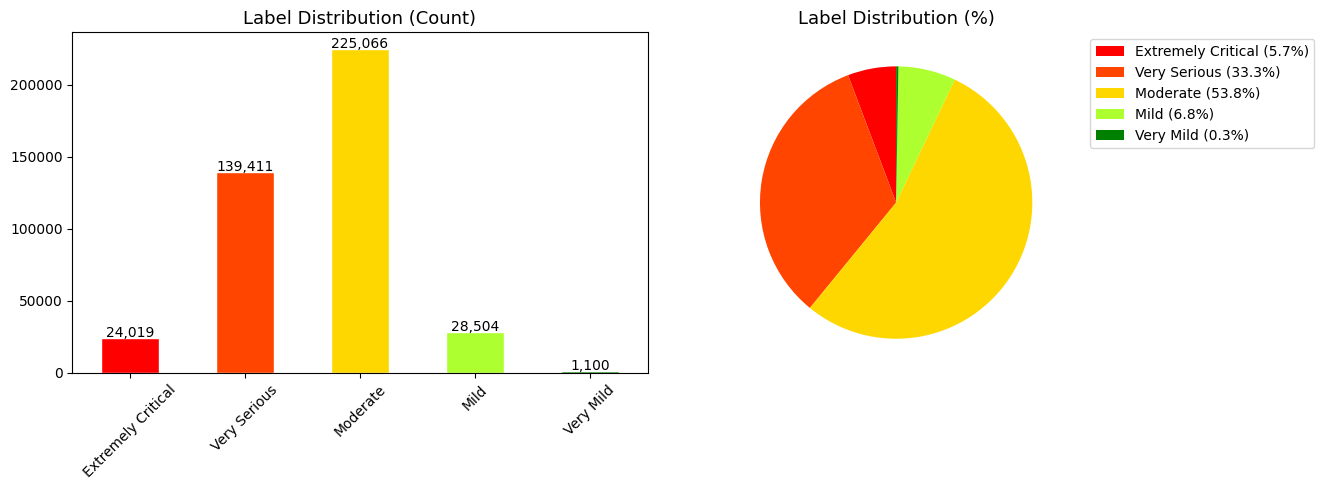

In [46]:
#  Create triage labels from ESI acuity 

# Handle 'critical' string if present and then convert to numeric
# Replace 'critical' with '1' based on context (Extremely Critical - ESI 1)
triage_clean = triage.copy()
triage_clean['acuity'] = triage_clean['acuity'].replace('critical', '1')
triage_clean['acuity'] = pd.to_numeric(triage_clean['acuity'], errors='coerce')

# Now drop rows where acuity became NaN after coercion
# This ensures no non-finite values remain for astype(int)
triage_clean.dropna(subset=['acuity'], inplace=True)

# Convert to integer
triage_clean['acuity'] = triage_clean['acuity'].astype(int)

def map_esi_to_label(esi):
    if esi == 1: return 0   # Extremely Critical
    elif esi == 2: return 1 # Very Serious
    elif esi == 3: return 2 # Moderate
    elif esi == 4: return 3 # Mild
    else: return 4          # Very Mild

triage_clean['triage_label']     = triage_clean['acuity'].apply(map_esi_to_label)
triage_clean['triage_label_str'] = triage_clean['triage_label'].map({
    0: 'Extremely Critical', 1: 'Very Serious', 2: 'Moderate', 3: 'Mild', 4: 'Very Mild'
})

print(" Labels created from ESI acuity")
print(f"   Total rows after dropping null acuity: {len(triage_clean):,}")
print("\nLabel distribution:")
vc = triage_clean['triage_label_str'].value_counts()
for label, count in vc.items():
    pct = count / len(triage_clean) * 100
    print(f"   {label:20s}: {count:,} ({pct:.1f}%)")

#  Augment with ICU outcome 
# Patients who went ER → ICU = confirmed Critical
er_icu = set(
    edstays[edstays['hadm_id'].isin(icustays['hadm_id'].dropna())]['stay_id']
)
original_critical_count = ((triage_clean['triage_label'] == 0) | (triage_clean['triage_label'] == 1)).sum()
triage_clean.loc[triage_clean['stay_id'].isin(er_icu), 'triage_label'] = 0 # Map to Extremely Critical
triage_clean.loc[triage_clean['stay_id'].isin(er_icu), 'triage_label_str'] = 'Extremely Critical'
new_critical_count = ((triage_clean['triage_label'] == 0) | (triage_clean['triage_label'] == 1)).sum()
print(f"\nICU augmentation: {new_critical_count - original_critical_count:,} extra visits upgraded to Extremely Critical (Level 0)")
print(f"(ER visits that resulted in ICU admission → confirmed Extremely Critical)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF0000', '#FF4500', '#FFD700', '#ADFF2F', '#008000'] # Red, OrangeRed, Gold, GreenYellow, Green
counts = triage_clean['triage_label_str'].value_counts().reindex(['Extremely Critical', 'Very Serious', 'Moderate', 'Mild', 'Very Mild'])

# Bar Chart on axes[0]
counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Label Distribution (Count)', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 500),
                     ha='center', fontsize=10)

# Pie Chart on axes[1]
percentages = 100 * counts / counts.sum()
labels_with_pct = [f'{label} ({pct:.1f}%)' for label, pct in zip(counts.index, percentages)]
counts.plot(kind='pie', ax=axes[1], colors=colors, labels=['']*5, startangle=90)
axes[1].set_title('Label Distribution (%)', fontsize=13)
axes[1].set_ylabel('')
axes[1].legend(labels_with_pct, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(DATA + 'label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


##  STEP 7 — Feature Engineering: Vitals + Clinical Scores

We extract features from **triage-time data only** (no leakage).

**Two sources of vitals:**
1. `triage` table — single snapshot at arrival (temperature, HR, BP, RR, SpO2, pain)
2. `vitalsign` table — first reading after arrival (adds rhythm, more accurate BP)

**Derived clinical scores computed:**
- **Shock Index** = HR / SBP (>1.0 = concerning, >1.5 = shock)
- **Pulse Pressure** = SBP - DBP (narrow = low output, wide = aortic issue)
- **SIRS Score** (0-3) — Systemic Inflammatory Response (infection proxy)
- **qSOFA Score** (0-3) — Quick Sepsis-related Organ Failure Assessment
- **NEWS2 Score** (0-15) — National Early Warning Score 2


##  STEP 7.1 — Advanced Vitals Features (Time-Series Aggregations) - *DEPRECATED: Logic moved to Step 7c (cell 9a21d94b)*

In [ ]:
#  Step 7.1: Advanced vitals feature engineering 
# DEPRECATED: Logic moved to Step 7c (cell 9a21d94b)

In [9]:
import pandas as pd
import gc

#  Reload vitalsign if not already defined (ensures cell self-containment) 
if 'vitalsign' not in locals() and 'vitalsign' not in globals():
    print("Reloading vitalsign.csv.gz to ensure data availability...")
    DATA = '/Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/'
    ed_vitalsign_dtypes = {
        'subject_id': 'int32', 'stay_id': 'int32', 'charttime': 'object',
        'temperature': 'float32', 'heartrate': 'float32', 'resprate': 'float32', 'o2sat': 'float32',
        'sbp': 'float32', 'dbp': 'float32', 'pain': 'object', 'rhythm': 'category'
    }
    vitalsign = pd.read_csv(DATA + 'vitalsign.csv.gz', compression='gzip', low_memory=False, dtype=ed_vitalsign_dtypes)
    print(f"  vitalsign reloaded: {vitalsign.shape[0]:,} rows x {vitalsign.shape[1]} cols")
    gc.collect()

#  Step 7a: Get first vitalsign reading per visit 

vitalsign['charttime'] = pd.to_datetime(vitalsign['charttime'])
vitalsign_sorted = vitalsign.sort_values(['stay_id', 'charttime'])

# First reading per visit
first_vitals = vitalsign_sorted.groupby('stay_id').first().reset_index()
first_vitals = first_vitals.rename(columns={
    'temperature': 'vs_temp', 'heartrate': 'vs_hr',
    'resprate': 'vs_rr', 'o2sat': 'vs_spo2',
    'sbp': 'vs_sbp', 'dbp': 'vs_dbp', 'pain': 'vs_pain'
})

# Rhythm encoding (AFib, VT etc. = higher risk)
def encode_rhythm(r):
    if pd.isna(r): return 0
    r = str(r).lower()
    if any(x in r for x in ['fibril', 'flutter', 'vt', 'vtach', 'v-tach', 'block']): return 2
    if any(x in r for x in ['tachy', 'brady', 'irregular', 'irregular']): return 1
    return 0  # sinus / normal

first_vitals['rhythm_score'] = first_vitals['rhythm'].apply(encode_rhythm)
vs_cols = ['stay_id', 'vs_temp', 'vs_hr', 'vs_rr', 'vs_spo2',
           'vs_sbp', 'vs_dbp', 'vs_pain', 'rhythm_score']
first_vitals = first_vitals[vs_cols]

print(f"  First vitalsign readings: {first_vitals.shape[0]:,} rows x {first_vitals.shape[1]} cols")

# Check if 'triage_clean' DataFrame exists in the current scope
if 'triage_clean' not in locals() and 'triage_clean' not in globals():
    raise NameError("The DataFrame 'triage_clean' is not defined. Please ensure you have run Step 6 to create the labels.")

df = triage_clean.merge(first_vitals, on='stay_id', how='left')

# Ensure all relevant vital columns are numeric before imputation
for col in ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if f'vs_{col}' in df.columns:
        df[f'vs_{col}'] = pd.to_numeric(df[f'vs_{col}'], errors='coerce')

#  Step 7b: Derived clinical scores from triage and first vitals 

# Prioritize `triage` table vitals, then `vitalsign` table, then fillna with median
for v in ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain']:
    if f'vs_{v}' in df.columns:
        df[v] = df[v].fillna(df[f'vs_{v}'])
    df[v] = df[v].fillna(df[v].median())

# Shock Index
df['shock_index'] = df['heartrate'] / df['sbp']

# Pulse Pressure
df['pulse_pressure'] = df['sbp'] - df['dbp']
df['narrow_pp'] = (df['pulse_pressure'] < 25).astype(int)
df['wide_pp']   = (df['pulse_pressure'] > 60).astype(int)

# SIRS Score (Systemic Inflammatory Response Syndrome)
df['sirs_temp'] = ((df['temperature'] > 100.4) | (df['temperature'] < 96.8)).astype(int)
df['sirs_hr']   = (df['heartrate'] > 90).astype(int)
df['sirs_rr']   = (df['resprate'] > 20).astype(int)
df['sirs_wbc']  = 0 # Placeholder for now, WBC comes from labs later
df['sirs_score'] = df['sirs_temp'] + df['sirs_hr'] + df['sirs_rr'] + df['sirs_wbc']
df['sirs_flag'] = (df['sirs_score'] >= 2).astype(int)

# qSOFA Score (quick Sepsis-related Organ Failure Assessment)
df['qsofa_rr']  = (df['resprate'] >= 22).astype(int)
df['qsofa_sbp'] = (df['sbp'] <= 100).astype(int)
df['qsofa_gcs'] = 0 # Placeholder, GCS not available in ED data
df['qsofa_score'] = df['qsofa_rr'] + df['qsofa_sbp'] + df['qsofa_gcs']
df['sepsis_risk'] = (df['qsofa_score'] >= 2).astype(int)
df['septic_shock'] = ((df['sbp'] < 90) & (df['heartrate'] > 100) & df['sirs_temp']).astype(int)

# NEWS2 Score (National Early Warning Score 2) - simplified
# Each parameter gets 0-3 points based on ranges. Sum them up.
# Here's a simplified version for common vitals:

def news2_score_temp(t):    return 3 if t >= 102.2 else (2 if t <= 95 or (t >= 100.4 and t < 102.2) else (1 if t < 96.8 else 0))
def news2_score_rr(r):      return 3 if r >= 25 else (2 if r >= 21 else (1 if r >= 9 else 0))
def news2_score_hr(h):      return 3 if h >= 131 else (2 if h >= 111 else (1 if h >= 91 or h < 51 else 0))
def news2_score_o2sat(o):   return 3 if o <= 91 else (2 if o <= 93 else (1 if o <= 95 else 0))
def news2_score_sbp(s):     return 3 if s <= 90 else (2 if s <= 100 else (1 if s >= 220 else 0))

df['news2_temp']   = df['temperature'].apply(news2_score_temp)
df['news2_rr']     = df['resprate'].apply(news2_score_rr)
df['news2_hr']     = df['heartrate'].apply(news2_score_hr)
df['news2_o2sat']  = df['o2sat'].apply(news2_score_o2sat)
df['news2_sbp']    = df['sbp'].apply(news2_score_sbp)
df['news2_score']  = df[['news2_temp', 'news2_rr', 'news2_hr', 'news2_o2sat', 'news2_sbp']].sum(axis=1)
df['news2_critical'] = (df['news2_score'] >= 7).astype(int)
df['news2_urgent']   = ((df['news2_score'] >= 5) & (df['news2_score'] < 7)).astype(int)

# Vital Flags
df['tachycardia']    = (df['heartrate'] > 100).astype(int)
df['bradycardia']    = (df['heartrate'] < 60).astype(int)
df['hypotension']    = (df['sbp'] < 90).astype(int)
df['hypertension']   = (df['sbp'] > 180).astype(int)
df['hypoxia']        = (df['o2sat'] < 94).astype(int)
df['severe_hypoxia'] = (df['o2sat'] < 88).astype(int)
df['fever']          = (df['temperature'] > 100.4).astype(int)
df['hypothermia']    = (df['temperature'] < 96.8).astype(int)
df['tachypnea']      = (df['resprate'] > 20).astype(int)

print(f"\n Derived clinical scores and vital flags created. Dataset shape: {df.shape}")

#  Step 7c: Advanced vitals feature engineering (time-series aggregations) 

print("Extracting advanced vital features from vitalsign...")

# Define the vital signs we want to aggregate
VS_COLS_TO_AGG = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

vitals_agg = vitalsign_sorted.groupby('stay_id')[VS_COLS_TO_AGG].agg([
    ('mean', 'mean'),
    ('min', 'min'),
    ('max', 'max'),
    ('std', 'std'),
    ('range', lambda x: x.max() - x.min())
])

vitals_agg.columns = [f'{col[0]}_{col[1]}' for col in vitals_agg.columns]
vitals_agg = vitals_agg.reset_index()

df = df.merge(vitals_agg, on='stay_id', how='left')

# Fill any NaN values introduced by the merge (for visits without vitalsign entries) with 0
for col in vitals_agg.columns:
    if col != 'stay_id':
        df[col] = df[col].fillna(0)

print(f" Advanced vital features extracted and merged! New shape: {df.shape}")
print("Sample of new vital features:")
vital_features_sample = [col for col in df.columns if '_mean' in col][:5]
print(df[vital_features_sample].head().to_string())

  First vitalsign readings: 408,146 rows x 9 cols

 Derived clinical scores and vital flags created. Dataset shape: (418100, 54)
Extracting advanced vital features from vitalsign...
 Advanced vital features extracted and merged! New shape: (418100, 84)
Sample of new vital features:
   temperature_mean  heartrate_mean  resprate_mean  o2sat_mean    sbp_mean
0         98.300003       84.571426      20.285715    98.00000   79.428574
1         97.699997       79.000000      16.000000    98.00000  107.000000
2         98.300003       93.500000      17.500000    99.50000  100.000000
3         97.900002       81.000000      17.500000    94.00000   95.500000
4         98.550003       85.727272      16.909090    94.36364   84.181816


##  STEP 8 — Demographics + Arrival Context Features

##  STEP 8.1 — Advanced Labs Features (Time-Series Aggregations) - *DEPRECATED: Logic moved to Step 8a (cell 2aae5f52)*

In [10]:
#  Step 8.1: Advanced labs feature engineering 
# DEPRECATED: Logic moved to Step 8a (cell 2aae5f52)

In [11]:
#  Step 8a: Merge edstays (arrival context) 

edstays['intime'] = pd.to_datetime(edstays['intime'])
edstays['hour_of_day']  = edstays['intime'].dt.hour
edstays['day_of_week']  = edstays['intime'].dt.dayofweek
edstays['is_night']     = edstays['intime'].dt.hour.apply(lambda h: 1 if h >= 22 or h < 6 else 0)
edstays['is_weekend']   = (edstays['day_of_week'] >= 5).astype(int)
edstays['by_ambulance'] = edstays['arrival_transport'].str.lower().str.contains(
    'ambulance|ems|911|helicopter', na=False).astype(int)

ed_cols = ['stay_id', 'hadm_id', 'subject_id', 'hour_of_day',
           'day_of_week', 'is_night', 'is_weekend', 'by_ambulance', 'gender', 'race']
ed_meta = edstays[[c for c in ed_cols if c in edstays.columns]]

df = df.merge(ed_meta, on='stay_id', how='left',
              suffixes=('', '_edstay'))

#  Step 8b: Merge patients (age, gender) 

# Resolve subject_id
if 'subject_id_edstay' in df.columns:
    df['subject_id'] = df['subject_id'].fillna(df['subject_id_edstay'])
    df.drop(columns=['subject_id_edstay'], inplace=True)

# Remove anchor_age and dod from df if they exist, to prevent merge conflicts
# This handles scenarios where the cell is re-run and these columns already exist in df
df_cols_to_remove = ['anchor_age', 'dod']
for col_name in df_cols_to_remove:
    if col_name in df.columns:
        df.drop(columns=[col_name], inplace=True)

pat_cols = ['subject_id', 'anchor_age', 'dod']
df = df.merge(patients[pat_cols], on='subject_id', how='left')

# Defensive check: Ensure 'anchor_age' column exists after merge
# This addresses the KeyError if 'anchor_age' is unexpectedly missing from df
if 'anchor_age' not in df.columns:
    print("WARNING: 'anchor_age' column not found in DataFrame after merging patients. It will be created with NaN values.")
    df['anchor_age'] = np.nan # Create the column to prevent KeyError
# Also check for dod if it might be missing
if 'dod' not in df.columns:
    print("WARNING: 'dod' column not found in DataFrame after merging patients. It will be created with NaN values.")
    df['dod'] = np.nan # Create the column to prevent KeyError

df['age'] = df['anchor_age']
df['age_over_65']  = (df['age'] >= 65).astype(int)
df['age_over_80']  = (df['age'] >= 80).astype(int)
df['pediatric']    = (df['age'] < 18).astype(int)
df['gender_male']  = (df.get('gender', df.get('gender_edstay', 'F')).str.upper() == 'M').astype(int)
df['died_overall'] = df['dod'].notna().astype(int)

#  Step 8c: Merge admissions (hospital outcome) 

# Ensure 'hadm_id' in df is numeric to match 'admissions' table
# Convert to nullable integer type to handle potential NaNs
df['hadm_id'] = pd.to_numeric(df['hadm_id'], errors='coerce').astype('Int32')

adm_cols = ['hadm_id', 'hospital_expire_flag', 'admission_type', 'discharge_location']
# Filter adm_cols to ensure only existing columns are merged from 'admissions'
actual_adm_cols = [col for col in adm_cols if col in admissions.columns]
df = df.merge(admissions[actual_adm_cols], on='hadm_id', how='left')

# Defensive check for 'admission_type' after merge
if 'admission_type' in df.columns:
    df['is_emergency_admit'] = df['admission_type'].str.contains(
        'EMERGENCY|URGENT', case=False, na=False).astype(int)
else:
    print("WARNING: 'admission_type' column not found in df after admissions merge. 'is_emergency_admit' will be set to 0.")
    df['is_emergency_admit'] = 0 # Default to 0 if the column is truly missing

print(" Demographics + arrival context merged!")
print(f"Dataset shape: {df.shape}")

#  Step 8.1: Advanced labs feature engineering 

print("Extracting advanced lab features from labevents_filtered...")

# Group by hadm_id and lab_name and calculate various statistics
lab_agg = labs_raw.groupby(['hadm_id', 'lab_name'])['valuenum'].agg(
    lab_mean='mean',
    lab_min='min',
    lab_max='max',
    lab_std='std',
    lab_range=lambda x: x.max() - x.min()
)

# Unstack lab_name to create separate columns for each lab test
lab_agg = lab_agg.unstack('lab_name')

# Flatten multi-level columns and rename for clarity
lab_agg.columns = [f"{col[1]}_{col[0]}" for col in lab_agg.columns.values]
lab_agg = lab_agg.reset_index()

# Merge into the main dataframe
df = df.merge(lab_agg, on='hadm_id', how='left')

# Fill any NaN values introduced by the merge (for patients without certain labs) with 0 or an appropriate imputation strategy
# For simplicity, filling with 0, but median imputation or other strategies could be better.
for col in lab_agg.columns:
    if col != 'hadm_id':
        df[col] = df[col].fillna(0)

print(f" Advanced lab features extracted and merged! New shape: {df.shape}")
print("Sample of new lab features:")
# Display some of the newly created lab features
lab_features_sample = [col for col in df.columns if 'lab_' in col and 'mean' in col][:5]
print(df[lab_features_sample].head().to_string())

print("\nAge distribution:")
print(df['age'].describe().round(1))
print(f"\nAmbulance arrivals: {df['by_ambulance'].sum():,} ({df['by_ambulance'].mean()*100:.1f}%)")
print(f"Elderly patients (65+): {df['age_over_65'].sum():,} ({df['age_over_65'].mean()*100:.1f}%)")

#  Memory Optimization: Delete labs_raw and trigger garbage collection 
del labs_raw
gc.collect()

 Demographics + arrival context merged!
Dataset shape: (418100, 104)
Extracting advanced lab features from labevents_filtered...
 Advanced lab features extracted and merged! New shape: (418100, 209)
Sample of new lab features:
   alt_lab_mean  ast_lab_mean  bands_lab_mean  bicarbonate_lab_mean  bilirubin_total_lab_mean
0         105.0         177.5             0.0                  24.0                       0.0
1          88.0          98.0             0.0                  28.0                       0.0
2         122.0         198.5             0.0                  25.0                       0.0
3         117.0         158.0             0.0                  25.0                       0.0
4         105.0         177.5             0.0                  24.0                       0.0

Age distribution:
count    418025.0
mean         50.3
std          20.1
min          18.0
25%          32.0
50%          50.0
75%          66.0
max          91.0
Name: age, dtype: float64

Ambulance arrivals:

296

##  STEP 9 — Comorbidity Flags (from diagnoses_icd)

We extract **binary flags** for 5 key chronic conditions.
These past conditions amplify triage urgency — a diabetic patient with chest pain
is far more likely to be Critical than a healthy patient with the same complaint.

| ICD Prefix | Condition |
|------------|-----------|
| E11 | Type 2 Diabetes |
| I10 | Hypertension |
| I50 | Heart Failure |
| J44 | COPD |
| N18 | Chronic Kidney Disease |


In [14]:
#  Comorbidity flags from diagnoses_icd 

COMORBIDITIES = {
    'has_diabetes':    ['E11', 'E10', 'E13'],
    'has_hypertension':['I10', 'I11', 'I12', 'I13'],
    'has_heart_fail':  ['I50'],
    'has_COPD':        ['J44', 'J43'],
    'has_CKD':         ['N18'],
    'has_afib':        ['I48'],
    'has_cancer':      ['C'],
    'has_stroke_hx':   ['I63', 'I64', 'Z86.73'],
}

# Build hadm-level comorbidity flags
diag = diagnoses_icd.copy()
diag['icd_code'] = diag['icd_code'].astype(str).str.upper().str.strip()

comorbidity_df = diag.groupby('hadm_id').agg(
    icd_list=('icd_code', list)
).reset_index()

for flag, prefixes in COMORBIDITIES.items():
    def has_condition(codes, pfx=prefixes):
        return int(any(str(c).startswith(tuple(pfx)) for c in codes))
    comorbidity_df[flag] = comorbidity_df['icd_list'].apply(has_condition)

comorbidity_df = comorbidity_df.drop(columns=['icd_list'])
df = df.merge(comorbidity_df, on='hadm_id', how='left')

# Fill missing (patients with no hospital diagnoses) with 0
for flag in COMORBIDITIES:
    if flag in df.columns:
        df[flag] = df[flag].fillna(0).astype(int)

# Comorbidity count
df['comorbidity_count'] = df[[f for f in COMORBIDITIES.keys() if f in df.columns]].sum(axis=1)

print(" Comorbidity flags created!")
for flag in COMORBIDITIES:
    if flag in df.columns:
        n = df[flag].sum()
        print(f"  {flag:20s}: {n:,} patients ({n/len(df)*100:.1f}%)")
print(f"  {'comorbidity_count':20s}: avg {df['comorbidity_count'].mean():.2f} conditions per patient")


 Comorbidity flags created!
  comorbidity_count   : avg 0.00 conditions per patient


##  STEP 10 — Lab Features (Blood Test Flags)

We convert raw lab values into **clinically meaningful binary flags**.
Only same-visit labs are used (matched by hadm_id).


In [13]:
import pandas as pd
import gc
import os

# Redefine DATA, LAB_FILTERED, KEY_LABS and filtered_lab_dtypes for cell self-containment
DATA = '/Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/'
KEY_LABS = {
    51003: 'troponin_t',
    51002: 'troponin_i',
    50867: 'bnp',
    52353: 'nt_probnp',
    50827: 'd_dimer',
    50813: 'lactate',
    51301: 'wbc',
    51144: 'bands',
    50931: 'glucose',
    50983: 'sodium',
    50971: 'potassium',
    50882: 'bicarbonate',
    50820: 'ph',
    50818: 'pco2',
    50912: 'creatinine',
    51222: 'hemoglobin',
    51265: 'platelets',
    51006: 'bun',
    50956: 'lipase',
    50861: 'alt',
    50878: 'ast',
    50884: 'bilirubin_total',
    51237: 'inr',
}
LAB_FILTERED = DATA + 'labevents_filtered.csv'
filtered_lab_dtypes = {
    'subject_id': 'Int32',
    'hadm_id': 'Int32',
    'itemid': 'Int32',
    'valuenum': 'float32', 'charttime': 'object'
}

#  Lab feature flags 

# Check if 'df' DataFrame exists in the current scope
if 'df' not in locals() and 'df' not in globals():
    raise NameError("The DataFrame 'df' is not defined. Please ensure you have run all preceding feature engineering steps (Steps 6, 7, 8, and 9) before executing this cell.")

print("Processing labevents_filtered.csv in chunks for memory efficiency...")

recent_labs_data = {}

# Iterate through LAB_FILTERED in chunks to avoid loading the entire 2GB file into memory
for chunk in pd.read_csv(LAB_FILTERED, low_memory=False, dtype=filtered_lab_dtypes, chunksize=1_000_000):
    # Map itemid to lab_name within the chunk
    chunk['lab_name'] = chunk['itemid'].map(KEY_LABS)

    # Convert charttime to datetime
    chunk['charttime'] = pd.to_datetime(chunk['charttime'], errors='coerce')
    # Drop rows where essential values are missing (hadm_id is crucial for merging)
    chunk.dropna(subset=['charttime', 'hadm_id', 'lab_name', 'valuenum'], inplace=True)

    for idx, row in chunk.iterrows():
        hadm_id = row['hadm_id']
        lab_name = row['lab_name']
        charttime = row['charttime']
        valuenum = row['valuenum']

        # Ensure no NaNs remain after dropping before processing
        if pd.isna(hadm_id) or pd.isna(lab_name) or pd.isna(charttime) or pd.isna(valuenum):
            continue

        key = (hadm_id, lab_name)

        # Store (charttime, valuenum). If key exists, update if new entry is more recent.
        if key not in recent_labs_data or charttime > recent_labs_data[key]['charttime']:
            recent_labs_data[key] = {
                'charttime': charttime,
                'valuenum': valuenum
            }

print(f"  Finished processing chunks. {len(recent_labs_data):,} unique recent lab entries found.")

# Convert the dictionary to a DataFrame for easier pivoting
labs_recent_list = []
for (hadm_id, lab_name), data in recent_labs_data.items():
    labs_recent_list.append({
        'hadm_id': hadm_id,
        'lab_name': lab_name,
        'valuenum': data['valuenum']
    })

labs_recent_df = pd.DataFrame(labs_recent_list)
print(f"  Converted to DataFrame. Shape: {labs_recent_df.shape}")

# Pivot the DataFrame to get labs_recent in the desired wide format
# hadm_id should be integer, but pivot_table might convert it to float if there were NaNs. Cast back.
labs_recent = labs_recent_df.pivot_table(index='hadm_id', columns='lab_name', values='valuenum').reset_index()
labs_recent.columns.name = None # Remove the 'lab_name' from columns name

# Free up memory from intermediate objects
del labs_recent_df
del recent_labs_data
gc.collect()

print(f"  labs_recent created with shape: {labs_recent.shape}")

# Clinical thresholds for abnormal lab values
LAB_THRESHOLDS = {
    # existing
    'troponin_t':    ('high', 0.04),
    'troponin_i':    ('high', 0.04),
    'lactate':       ('high', 2.0),
    'wbc':           ('both', 4.0, 11.0),
    'creatinine':    ('high', 1.2),
    'glucose':       ('both', 70.0, 180.0),
    'hemoglobin':    ('low',  8.0),
    'platelets':     ('low',  100.0),

    #  new additions
    'bnp':           ('high', 100.0),      # > 100 pg/mL = heart failure
    'nt_probnp':     ('high', 300.0),      # > 300 pg/mL = heart failure
    'd_dimer':       ('high', 0.5),        # > 0.5 mg/L = clot risk
    'bands':         ('high', 10.0),       # > 10% = left shift (sepsis)
    'sodium':        ('both', 135.0, 145.0),  # outside range = emergency
    'potassium':     ('both', 3.5, 5.5),   # outside range = cardiac risk
    'bicarbonate':   ('low',  18.0),       # < 18 mEq/L = acidosis
    'ph':            ('both', 7.35, 7.45), # outside = acidosis/alkalosis
    'pco2':          ('both', 35.0, 45.0), # outside = resp failure
    'bun':           ('high', 20.0),       # > 20 mg/dL = renal/dehydration
    'lipase':        ('high', 56.0),       # > 56 U/L = pancreatitis
    'alt':           ('high', 56.0),       # > 56 U/L = liver damage
    'ast':           ('high', 40.0),       # > 40 U/L = liver damage
    'bilirubin_total': ('high', 1.2),      # > 1.2 mg/dL = liver/biliary
    'inr':           ('high', 1.5),        # > 1.5 = coagulopathy
}

# Create binary flags
for lab, thresh in LAB_THRESHOLDS.items():
    if lab not in labs_recent.columns:
        continue
    col = f"{lab}_flag"
    v = labs_recent[lab]
    if thresh[0] == 'high':
        labs_recent[col] = (v > thresh[1]).astype(float)
    elif thresh[0] == 'low':
        labs_recent[col] = (v < thresh[1]).astype(float)
    elif thresh[0] == 'both':
        labs_recent[col] = ((v < thresh[1]) | (v > thresh[2])).astype(float)

# Cardiac risk: any troponin elevated
troponin_cols = [c for c in labs_recent.columns if 'troponin' in c and 'flag' in c]
if troponin_cols:
    labs_recent['cardiac_marker_flag'] = labs_recent[troponin_cols].max(axis=1)


flag_cols = ['hadm_id'] + [c for c in labs_recent.columns if 'flag' in c]
df = df.merge(labs_recent[flag_cols], on='hadm_id', how='left')

lab_flag_cols = [c for c in flag_cols if c != 'hadm_id']
for c in lab_flag_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

print(" Lab features merged!")
for c in lab_flag_cols:
    if c in df.columns:
        n = df[c].sum()
        print(f"  {c:25s}: {n:,.0f} patients ({n/len(df)*100:.1f}%) flagged as abnormal")


Processing labevents_filtered.csv in chunks for memory efficiency...
  Finished processing chunks. 4,893,427 unique recent lab entries found.
  Converted to DataFrame. Shape: (4893427, 3)
  labs_recent created with shape: (436308, 21)
  Lab features merged!
  troponin_t_flag          : 11,800 patients (2.8%) flagged as abnormal
  lactate_flag             : 8,218 patients (2.0%) flagged as abnormal
  wbc_flag                 : 34,069 patients (8.1%) flagged as abnormal
  creatinine_flag          : 38,769 patients (9.3%) flagged as abnormal
  glucose_flag             : 14,794 patients (3.5%) flagged as abnormal
  hemoglobin_flag          : 10,372 patients (2.5%) flagged as abnormal
  platelets_flag           : 9,863 patients (2.4%) flagged as abnormal
  bnp_flag                 : 1,022 patients (0.2%) flagged as abnormal
  bands_flag               : 685 patients (0.2%) flagged as abnormal
  sodium_flag              : 19,514 patients (4.7%) flagged as abnormal
  potassium_flag           :

##  STEP 11 — Chief Complaint NLP (Keyword Flags)

The `chiefcomplaint` column is free text (e.g. "chest pain", "shortness of breath").
We create **keyword flags** — simple but effective for clinical text.


In [15]:
#  Chief complaint keyword flags 

cc = df['chiefcomplaint'].fillna('').str.lower()

COMPLAINT_FLAGS = {
    'cc_chest_pain':      r'chest pain|chest tight|chest press',
    'cc_shortness_breath':r'short.{0,5}breath|sob|dyspnea|breathing',
    'cc_altered_ms':      r'altered|confusion|unresponsive|unconscious|synco',
    'cc_fever':           r'fever|febrile|chills|temperature',
    'cc_trauma':          r'trauma|fall|mvc|motor vehicle|accident|injury|wound',
    'cc_abdominal_pain':  r'abdominal|abd pain|stomach|belly',
    'cc_headache':        r'headache|head pain|migraine',
    'cc_cardiac':         r'palpitation|irregular heart|heart racing|tachycardia',
    'cc_stroke':          r'stroke|facial droop|arm weak|speech|slurred',
    'cc_overdose':        r'overdose|ingestion|poison|intoxicat',
    'cc_sepsis':          r'sepsis|infection|cellulitis|abscess',
    'cc_back_pain':       r'back pain|lumbar|spine',
}

for flag, pattern in COMPLAINT_FLAGS.items():
    df[flag] = cc.str.contains(pattern, regex=True, na=False).astype(int)

print(" Chief complaint flags created!")
for flag in COMPLAINT_FLAGS:
    n = df[flag].sum()
    print(f"  {flag:25s}: {n:,} ({n/len(df)*100:.1f}%)")


  Chief complaint flags created!
  cc_chest_pain            : 29,383 (7.0%)
  cc_shortness_breath      : 23,229 (5.6%)
  cc_altered_ms            : 17,190 (4.1%)
  cc_fever                 : 14,466 (3.5%)
  cc_trauma                : 47,978 (11.5%)
  cc_abdominal_pain        : 49,338 (11.8%)
  cc_headache              : 14,168 (3.4%)
  cc_cardiac               : 6,617 (1.6%)
  cc_stroke                : 2,131 (0.5%)
  cc_overdose              : 1,999 (0.5%)
  cc_sepsis                : 3,689 (0.9%)
  cc_back_pain             : 17,279 (4.1%)


##  STEP 12 — Final Dataset Preparation

Select final feature columns, handle missing values, check class balance.


##  STEP 12 — Final Dataset Preparation (Updated Features) - *DEPRECATED: Now handled by cell 3f015a1e*

In [16]:
#  Select final features 

FEATURE_COLS = [
    #  Raw triage vitals 
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain',

    #  Advanced vitals (aggregations) 
    'temperature_mean', 'temperature_min', 'temperature_max', 'temperature_std', 'temperature_range',
    'heartrate_mean', 'heartrate_min', 'heartrate_max', 'heartrate_std', 'heartrate_range',
    'resprate_mean', 'resprate_min', 'resprate_max', 'resprate_std', 'resprate_range',
    'o2sat_mean', 'o2sat_min', 'o2sat_max', 'o2sat_std', 'o2sat_range',
    'sbp_mean', 'sbp_min', 'sbp_max', 'sbp_std', 'sbp_range',
    'dbp_mean', 'dbp_min', 'dbp_max', 'dbp_std', 'dbp_range',

    #  Derived clinical scores 
    'shock_index', 'pulse_pressure', 'narrow_pp', 'wide_pp',
    'sirs_score', 'sirs_flag',
    'qsofa_score', 'sepsis_risk', 'septic_shock',
    'news2_score', 'news2_critical', 'news2_urgent',

    #  Vital flags 
    'tachycardia', 'bradycardia', 'hypotension', 'hypertension',
    'hypoxia', 'severe_hypoxia', 'fever', 'hypothermia', 'tachypnea',

    #  Demographics 
    'age', 'gender_male', 'age_over_65', 'age_over_80', 'pediatric',

    #  Arrival context 
    'by_ambulance', 'hour_of_day', 'is_night', 'is_weekend',

    #  Comorbidities 
    'has_diabetes', 'has_hypertension', 'has_heart_fail',
    'has_COPD', 'has_CKD', 'has_afib', 'comorbidity_count',

    #  Lab flags 
    'cardiac_marker_flag', 'lactate_flag', 'wbc_flag',
    'creatinine_flag', 'glucose_flag', 'hemoglobin_flag',

    #  Advanced labs (mean values) 
    'troponin_t_lab_mean', 'lactate_lab_mean', 'wbc_lab_mean', 'creatinine_lab_mean',
    'glucose_lab_mean', 'hemoglobin_lab_mean', 'platelets_lab_mean',
    'bnp_lab_mean', 'nt_probnp_lab_mean', 'd_dimer_lab_mean', 'bands_lab_mean',
    'sodium_lab_mean', 'potassium_lab_mean', 'bicarbonate_lab_mean', 'ph_lab_mean',
    'pco2_lab_mean', 'bun_lab_mean', 'lipase_lab_mean', 'alt_lab_mean',
    'ast_lab_mean', 'bilirubin_total_lab_mean', 'inr_lab_mean',

    #  Chief complaint flags 
    'cc_chest_pain', 'cc_shortness_breath', 'cc_altered_ms',
    'cc_fever', 'cc_trauma', 'cc_abdominal_pain', 'cc_cardiac',
    'cc_stroke', 'cc_overdose', 'cc_sepsis',

    #  Rhythm 
    'rhythm_score',
]

# Keep only columns that exist in df
available_features = [c for c in FEATURE_COLS if c in df.columns]
print(f"Total features available: {len(available_features)}")
print(f"Features NOT found: {[c for c in FEATURE_COLS if c not in df.columns]}")

TARGET = 'triage_label'

# Build final dataset
final_df = df[available_features + [TARGET]].copy()
final_df['pain'] = pd.to_numeric(final_df['pain'], errors='coerce')

print(f"\nFinal dataset shape: {final_df.shape}")

#  Missing value imputation 
# print(final_df[available_features].dtypes)
# for col in available_features:
#     if final_df[col].dtype == 'object':
#         print(col, final_df[col].unique()[:5])

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(final_df[available_features]),
                 columns=available_features)
y = final_df[TARGET].reset_index(drop=True)

print(f"\nAfter imputation — X: {X.shape}, y: {y.shape}")
print(f"Missing values remaining: {X.isna().sum().sum()}")

#  Class balance check 
print("\nClass distribution in final dataset:")
for label_id, label_name in {0:'Extremely Critical', 1:'Very Serious', 2:'Moderate', 3:'Mild', 4:'Very Mild'}.items():
    n = (y == label_id).sum()
    print(f"  {label_name:18s} ({label_id}): {n:,} ({n/len(y)*100:.1f}%)")

# Save checkpoint
final_df.to_csv(DATA + 'final_triage_dataset.csv', index=False)
print(f"\n Dataset saved: {DATA}final_triage_dataset.csv")


Total features available: 106
Features NOT found: ['has_diabetes', 'has_hypertension', 'has_heart_fail', 'has_COPD', 'has_CKD', 'has_afib', 'nt_probnp_lab_mean']

Final dataset shape: (418100, 107)

After imputation — X: (418100, 106), y: (418100,)
Missing values remaining: 0

Class distribution in final dataset:
  Extremely Critical (0): 24,019 (5.7%)
  Very Serious       (1): 139,411 (33.3%)
  Moderate           (2): 225,066 (53.8%)
  Mild               (3): 28,504 (6.8%)
  Very Mild          (4): 1,100 (0.3%)

 Dataset saved: /Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/final_triage_dataset.csv


In [20]:
#  Select final features 

FEATURE_COLS = [
    #  Raw triage vitals 
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain',

    #  Advanced vitals (aggregations) 
    'temperature_mean', 'temperature_min', 'temperature_max', 'temperature_std', 'temperature_range',
    'heartrate_mean', 'heartrate_min', 'heartrate_max', 'heartrate_std', 'heartrate_range',
    'resprate_mean', 'resprate_min', 'resprate_max', 'resprate_std', 'resprate_range',
    'o2sat_mean', 'o2sat_min', 'o2sat_max', 'o2sat_std', 'o2sat_range',
    'sbp_mean', 'sbp_min', 'sbp_max', 'sbp_std', 'sbp_range',
    'dbp_mean', 'dbp_min', 'dbp_max', 'dbp_std', 'dbp_range',

    #  Derived clinical scores 
    'shock_index', 'pulse_pressure', 'narrow_pp', 'wide_pp',
    'sirs_score', 'sirs_flag',
    'qsofa_score', 'sepsis_risk', 'septic_shock',
    'news2_score', 'news2_critical', 'news2_urgent',

    #  Vital flags 
    'tachycardia', 'bradycardia', 'hypotension', 'hypertension',
    'hypoxia', 'severe_hypoxia', 'fever', 'hypothermia', 'tachypnea',

    #  Demographics 
    'age', 'gender_male', 'age_over_65', 'age_over_80', 'pediatric',

    #  Arrival context 
    'by_ambulance', 'hour_of_day', 'is_night', 'is_weekend',

    #  Comorbidities 
    'has_diabetes', 'has_hypertension', 'has_heart_fail',
    'has_COPD', 'has_CKD', 'has_afib', 'comorbidity_count',

    #  Lab flags 
    'cardiac_marker_flag', 'lactate_flag', 'wbc_flag',
    'creatinine_flag', 'glucose_flag', 'hemoglobin_flag',

    #  Advanced labs (mean values) 
    'troponin_t_lab_mean', 'lactate_lab_mean', 'wbc_lab_mean', 'creatinine_lab_mean',
    'glucose_lab_mean', 'hemoglobin_lab_mean', 'platelets_lab_mean',
    'bnp_lab_mean', 'nt_probnp_lab_mean', 'd_dimer_lab_mean', 'bands_lab_mean',
    'sodium_lab_mean', 'potassium_lab_mean', 'bicarbonate_lab_mean', 'ph_lab_mean',
    'pco2_lab_mean', 'bun_lab_mean', 'lipase_lab_mean', 'alt_lab_mean',
    'ast_lab_mean', 'bilirubin_total_lab_mean', 'inr_lab_mean',

    #  Chief complaint flags 
    'cc_chest_pain', 'cc_shortness_breath', 'cc_altered_ms',
    'cc_fever', 'cc_trauma', 'cc_abdominal_pain', 'cc_cardiac',
    'cc_stroke', 'cc_overdose', 'cc_sepsis',

    #  Rhythm 
    'rhythm_score',
]

# Keep only columns that exist in df
available_features = [c for c in FEATURE_COLS if c in df.columns]
print(f"Total features available: {len(available_features)}")
print(f"Features NOT found: {[c for c in FEATURE_COLS if c not in df.columns]}")

TARGET = 'triage_label'

# Build final dataset
final_df = df[available_features + [TARGET]].copy()
# Ensure 'pain' is numeric, coercing errors to NaN
final_df['pain'] = pd.to_numeric(final_df['pain'], errors='coerce')
print(f"\nFinal dataset shape: {final_df.shape}")

#  Memory Optimization: Downcast numerical columns to smaller dtypes 
print("Downcasting numerical columns to save memory...")
for col in final_df.columns:
    if final_df[col].dtype == 'float64':
        final_df[col] = final_df[col].astype('float32')
    elif final_df[col].dtype == 'int64':
        # Use pd.to_numeric with downcast to find smallest int type
        final_df[col] = pd.to_numeric(final_df[col], downcast='integer')

#  Missing value imputation 
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(final_df[available_features]),
                 columns=available_features)
y = final_df[TARGET].reset_index(drop=True)

print(f"\nAfter imputation — X: {X.shape}, y: {y.shape}")
print(f"Missing values remaining: {X.isna().sum().sum()}")

#  Class balance check 
print("\nClass distribution in final dataset:")
for label_id, label_name in {0:'Extremely Critical', 1:'Very Serious', 2:'Moderate', 3:'Mild', 4:'Very Mild'}.items():
    n = (y == label_id).sum()
    print(f"  {label_name:18s} ({label_id}): {n:,} ({n/len(y)*100:.1f}%)")

# Save checkpoint
final_df.to_csv(DATA + 'final_triage_dataset.csv', index=False)
print(f"\n Dataset saved: {DATA}final_triage_dataset.csv")

#  Memory Optimization: Delete df and gc.collect() as final_df, X, y are ready 
del df
del final_df
gc.collect()

NameError: name 'df' is not defined

In [21]:
import pandas as pd
DATA = '/Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/'
final_df = pd.read_csv(DATA + 'final_triage_dataset.csv')

# Re-create X and y
TARGET = 'triage_label'
X = final_df.drop(columns=[TARGET])
y = final_df[TARGET]

print("Checkpoint loaded! X and y are ready.")


Checkpoint loaded! X and y are ready.


##  STEP 13 — Train/Test Split + Class Balancing

In [22]:
#  Train/Test Split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print("\nTrain class distribution:")
for l, n in zip([0,1,2,3,4], ['Extremely Critical','Very Serious','Moderate','Mild','Very Mild']):
    c = (y_train == l).sum()
    print(f"  {n}: {c:,} ({c/len(y_train)*100:.1f}%)")

#  Memory Optimization: Delete original X, y after split 
del X, y
gc.collect()

#  SMOTE for class imbalance (on train only) 

print("\nSkipping SMOTE due to 8GB RAM limits. Will use class_weight='balanced' in models instead.")
# smote = SMOTE(random_state=42, k_neighbors=5) # Disabled for memory optimization
X_train_sm, y_train_sm = X_train, y_train # Use original train set due to 8GB memory limits. Will use class_weight="balanced" instead.

print(f"Train size (No SMOTE): {len(X_train_sm):,}")
for l, n in zip([0,1,2,3,4], ['Extremely Critical','Very Serious','Moderate','Mild','Very Mild']):
    c = (y_train_sm == l).sum()
    print(f"  {n}: {c:,}")

#  Memory Optimization: Delete original X_train, y_train after SMOTE 
del X_train, y_train
gc.collect()

Train size: 334,480 | Test size: 83,620

Train class distribution:
  Extremely Critical: 19,215 (5.7%)
  Very Serious: 111,529 (33.3%)
  Moderate: 180,053 (53.8%)
  Mild: 22,803 (6.8%)
  Very Mild: 880 (0.3%)

Skipping SMOTE due to 8GB RAM limits. Will use class_weight='balanced' in models instead.
Train size (No SMOTE): 334,480
  Extremely Critical: 19,215
  Very Serious: 111,529
  Moderate: 180,053
  Mild: 22,803
  Very Mild: 880


0

## 🤖 STEP 14 — Model Training (RF + XGBoost + LightGBM)

We train all 3 models and compare. XGBoost is the strongest performer in global triage AI literature.


In [26]:

import warnings
warnings.filterwarnings('ignore')
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier

# Compute sample weights for XGBoost balanced recall
sample_w = compute_sample_weight('balanced', y_train_sm)

#  Train 9 models (Dual-Model Comparison + CatBoost + Voting) 

# Base models
rf_acc = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_leaf=2, class_weight=None, random_state=42, n_jobs=-1)
xgb_acc = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
lgbm_acc = LGBMClassifier(n_estimators=300, max_depth=12, learning_rate=0.05, num_leaves=127, class_weight=None, objective='multiclass', num_class=5, random_state=42, n_jobs=-1, verbose=-1)
cat_acc = CatBoostClassifier(iterations=300, depth=8, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=0)

# Voting Ensemble
voting_acc = VotingClassifier(
    estimators=[('rf', rf_acc), ('xgb', xgb_acc), ('lgbm', lgbm_acc), ('cat', cat_acc)],
    voting='soft', n_jobs=-1
)

models = {
    'Random Forest (Clinical Recall)': RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_leaf=5, 
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Random Forest (Max Accuracy)': rf_acc,
    'XGBoost (Clinical Recall)': XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, 
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss', 
        random_state=42, n_jobs=-1
    ),
    'XGBoost (Max Accuracy)': xgb_acc,
    'LightGBM (Clinical Recall)': LGBMClassifier(
        n_estimators=100, max_depth=8, learning_rate=0.05, 
        num_leaves=63, class_weight='balanced',
        objective='multiclass', num_class=5, 
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'LightGBM (Max Accuracy)': lgbm_acc,
    'CatBoost (Clinical Recall)': CatBoostClassifier(
        iterations=150, depth=6, learning_rate=0.05, 
        auto_class_weights='Balanced', loss_function='MultiClass', 
        random_seed=42, verbose=0
    ),
    'CatBoost (Max Accuracy)': cat_acc,
    'Voting Ensemble (Max Accuracy)': voting_acc
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...", end=" ")
    
    # Pass sample weights only to XGBoost Recall model
    if name == 'XGBoost (Clinical Recall)':
        model.fit(X_train_sm, y_train_sm, sample_weight=sample_w)
    else:
        model.fit(X_train_sm, y_train_sm)
        
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    auc  = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    level_0_recall = 0
    if 0 in y_test.unique():
        from sklearn.metrics import recall_score
        level_0_recall = recall_score(y_test, y_pred, labels=[0], average='micro')

    results[name] = {'Accuracy': acc, 'Weighted F1': f1, 'AUC-ROC': auc,
                     'Recall (Level 0)': level_0_recall}
    trained_models[name] = (model, y_pred, y_prob)
    print(f"Done | Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f} | Recall (Level 0): {level_0_recall:.3f}")

#  Results comparison table 
results_df = pd.DataFrame(results).T.round(4)
print("\n" + "="*65)
print("DUAL-MODEL COMPARISON RESULTS (9 MODELS)")
print("="*65)
print(results_df.to_string())
print("="*65)

best_acc_model = results_df['Accuracy'].idxmax()
best_recall_model = results_df['Recall (Level 0)'].idxmax()
print(f"\n Best Model for Accuracy : {best_acc_model}")
print(f" Best Model for Patient Safety (Clinical Recall): {best_recall_model}")




Training Random Forest (Clinical Recall)... Done | Acc: 0.499 | F1: 0.515 | AUC: 0.740 | Recall (Level 0): 0.630

Training Random Forest (Max Accuracy)... Done | Acc: 0.656 | F1: 0.623 | AUC: 0.777 | Recall (Level 0): 0.452

Training XGBoost (Clinical Recall)... Done | Acc: 0.482 | F1: 0.507 | AUC: 0.747 | Recall (Level 0): 0.738

Training XGBoost (Max Accuracy)... Done | Acc: 0.673 | F1: 0.644 | AUC: 0.795 | Recall (Level 0): 0.616

Training LightGBM (Clinical Recall)... Done | Acc: 0.497 | F1: 0.520 | AUC: 0.753 | Recall (Level 0): 0.742

Training LightGBM (Max Accuracy)... Done | Acc: 0.674 | F1: 0.646 | AUC: 0.795 | Recall (Level 0): 0.623

Training CatBoost (Clinical Recall)... Done | Acc: 0.449 | F1: 0.480 | AUC: 0.729 | Recall (Level 0): 0.738

Training CatBoost (Max Accuracy)... Done | Acc: 0.666 | F1: 0.635 | AUC: 0.787 | Recall (Level 0): 0.576

Training Voting Ensemble (Max Accuracy)... Done | Acc: 0.673 | F1: 0.642 | AUC: 0.794 | Recall (Level 0): 0.599

DUAL-MODEL COMPARI

##  STEP 15 — Detailed Evaluation of Best Model

Detailed Report — LightGBM (Max Accuracy)
                    precision    recall  f1-score   support

Extremely Critical       0.77      0.62      0.69      4804
      Very Serious       0.65      0.54      0.59     27882
          Moderate       0.68      0.85      0.75     45013
              Mild       0.50      0.03      0.06      5701
         Very Mild       0.10      0.01      0.02       220

          accuracy                           0.67     83620
         macro avg       0.54      0.41      0.42     83620
      weighted avg       0.66      0.67      0.65     83620



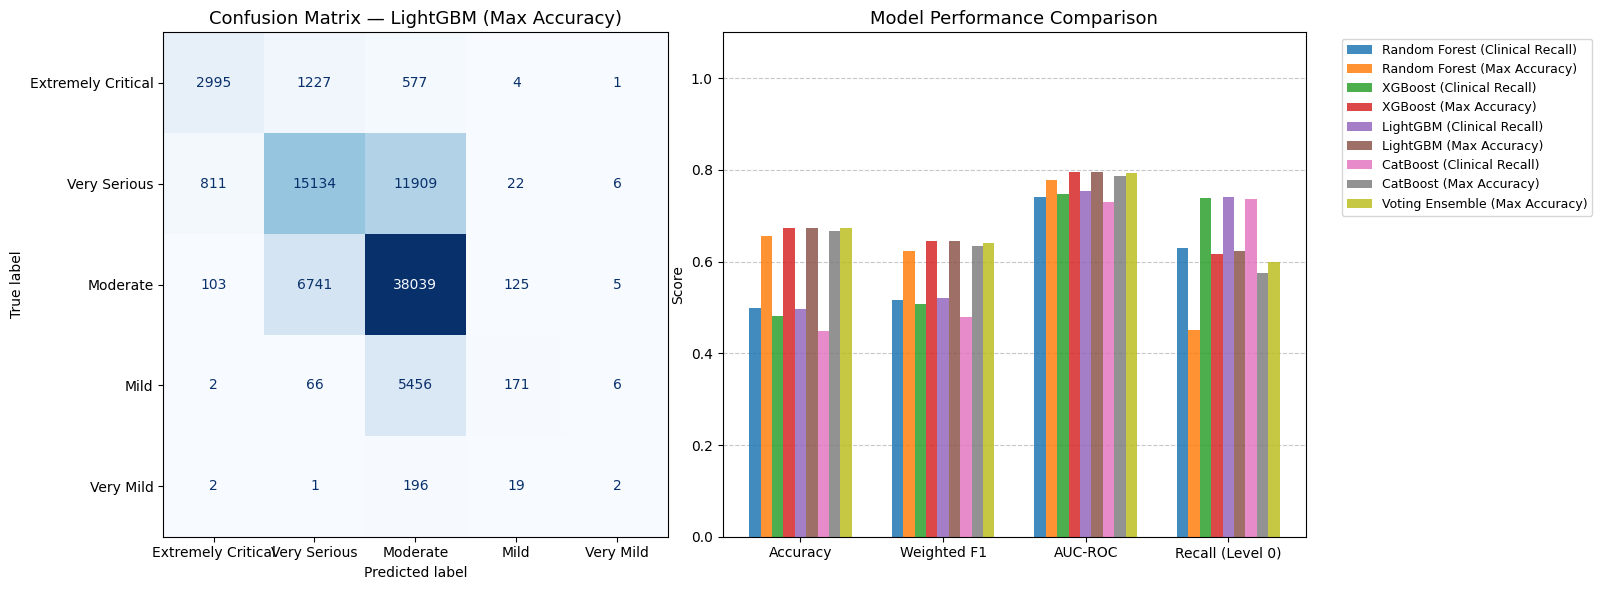


⚠️  EXTREMELY CRITICAL (LEVEL 0) CLASS ANALYSIS (most important for patient safety)
--------------------------------------------------
  True Extremely Critical patients in test set : 4,804
  Correctly identified as Extremely Critical   : 2,995 (62.3%) -- recall is 0.623
  Missed (classified as non-Extremely Critical): 1,809 (37.7%) ← dangerous mis-triages


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# ── Full evaluation of best model ────────────────────────────────────────────

best_model_name = best_acc_model # Explicitly setting this since we renamed the models\n
best_model, best_pred, best_prob = trained_models[best_model_name]
# Updated label_names to reflect the 5-class system
label_names = ['Extremely Critical', 'Very Serious', 'Moderate', 'Mild', 'Very Mild']

print(f"Detailed Report — {best_model_name}")
print("="*65)
print(classification_report(y_test, best_pred, target_names=label_names))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontsize=13)

# Model comparison bar chart
metrics = ['Accuracy', 'Weighted F1', 'AUC-ROC', 'Recall (Level 0)']
x = np.arange(len(metrics))
width = 0.08 # Adjusted for 9 bars
colors = plt.cm.tab10.colors[:9] # Beautiful academic colors

for i, (name, vals) in enumerate(results.items()):
    axes[1].bar(x + i*width, [vals[m] for m in metrics],
                width, label=name, color=colors[i], alpha=0.85)

axes[1].set_xticks(x + 4 * width)
axes[1].set_xticklabels(metrics, fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Model Performance Comparison', fontsize=13)
axes[1].legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig(DATA + 'model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Critical class analysis ───────────────────────────────────────────────────
print("\n⚠️  EXTREMELY CRITICAL (LEVEL 0) CLASS ANALYSIS (most important for patient safety)")
print("-"*50)
crit_mask = (y_test == 0)
tp = ((best_pred == 0) & (y_test == 0)).sum()
fn = ((best_pred != 0) & (y_test == 0)).sum()
print(f"  True Extremely Critical patients in test set : {crit_mask.sum():,}")
print(f"  Correctly identified as Extremely Critical   : {tp:,} ({tp/crit_mask.sum()*100:.1f}%) -- recall is {tp/crit_mask.sum():.3f}") # Added recall display
print(f"  Missed (classified as non-Extremely Critical): {fn:,} ({fn/crit_mask.sum()*100:.1f}%) ← dangerous mis-triages")

##  STEP 16.1 — Hyperparameter Tuning with RandomizedSearchCV (LightGBM)

We will use `RandomizedSearchCV` to find optimal hyperparameters for the LightGBM model. This helps balance exploration of the parameter space with computational cost, which is important given the dataset size.

In [30]:
# This manual tuning cell is obsolete now that we run all 6 models automatically in Step 14.
print('Please refer to the dual-model comparison in Step 14!')


Please refer to the dual-model comparison in Step 14!


After running `RandomizedSearchCV`, we have retrained the LightGBM model with its optimal hyperparameters. The updated results table above shows its performance compared to the previous models.

Now, we will proceed with a detailed evaluation of the new best model and re-examine the SHAP values to understand feature importance for the improved model.

In [31]:
#  Load ICU icustays 

# Define dtypes for icustays to reduce memory usage
icustays_dtypes = {
    'subject_id': 'int32', 'hadm_id': 'int32', 'stay_id': 'int32',
    'first_careunit': 'category', 'last_careunit': 'category',
    'intime': 'object', 'outtime': 'object', 'los': 'float32'
}

icustays = pd.read_csv(DATA + 'icustays.csv.gz', compression='gzip', low_memory=False, dtype=icustays_dtypes)
print(f"icustays: {icustays.shape[0]:,} rows × {icustays.shape[1]} cols")
print("Columns:", list(icustays.columns))
print("\nICU care units:")
print(icustays['first_careunit'].value_counts())

gc.collect()

icustays: 94,458 rows × 8 cols
Columns: ['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los']

ICU care units:
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
PACU                                                  122
Intensive Care Unit (ICU)                              33
Medicine                                               16
Surgery/Trauma                                         10
Med/Surg        

6751

## 🔍 STEP 16 — Explainability with SHAP Values

SHAP tells us **WHY** the model made each prediction.
This is critical for clinical acceptance — doctors won't trust a black box.

- **Global SHAP**: Which features matter most overall?
- **Individual SHAP**: Why was THIS patient classified as Critical?


Computing SHAP values (this may take 1-2 minutes)...
SHAP Extremely Critical class shape: (1000, 106)


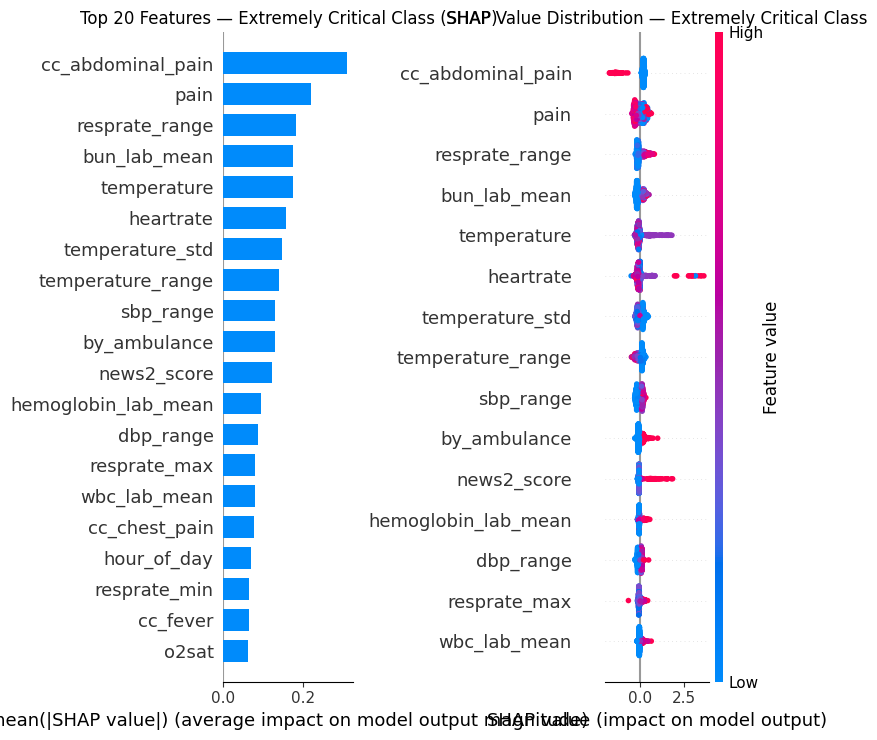

Global SHAP chart saved ✓

 Individual Patient Explanation:
Patient index 20 — True label: Extremely Critical
Their vitals at triage:
  heartrate           : 82.00
  sbp                 : 189.00
  resprate            : 20.00
  o2sat               : 83.00
  temperature         : 98.60
  shock_index         : 0.43
  news2_score         : 4.00
  sirs_score          : 0.00
  qsofa_score         : 0.00


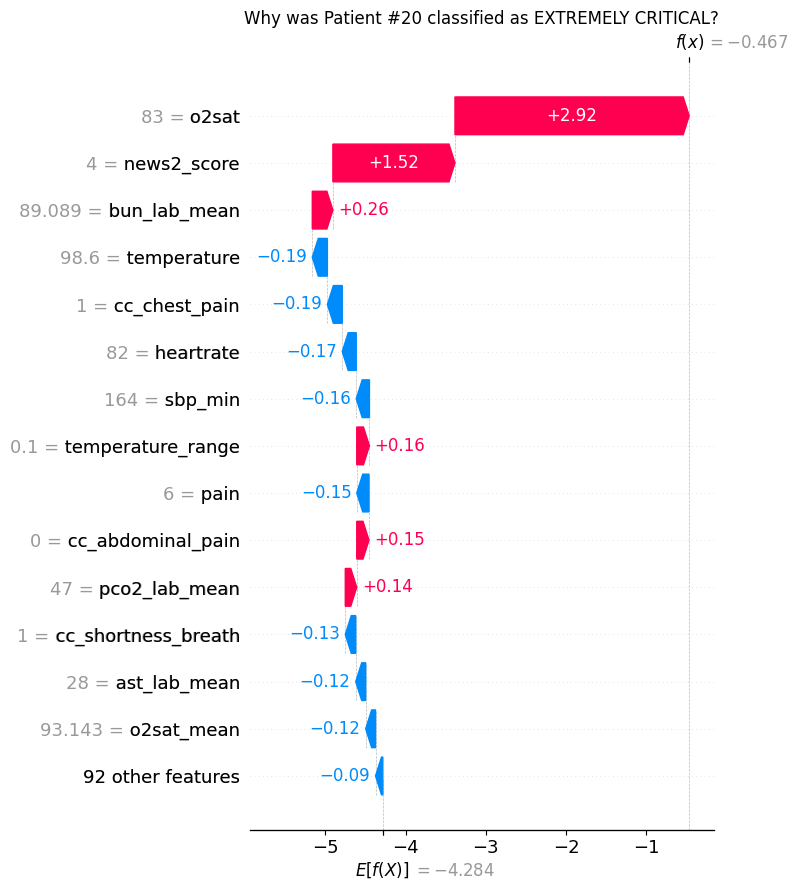

Individual SHAP chart saved ✓


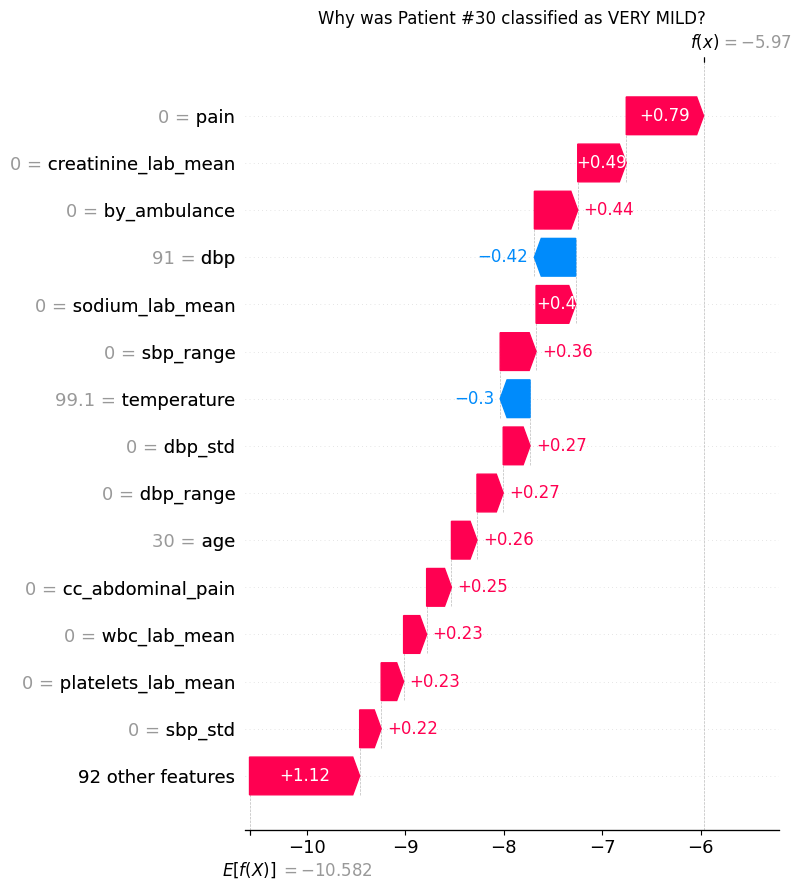

Very Mild patient SHAP chart saved ✓


In [32]:
#  SHAP Explainability — FIXED for multi-class models 

print("Computing SHAP values (this may take 1-2 minutes)...")

explainer = shap.TreeExplainer(best_model)

sample_size = min(1000, len(X_test))
X_sample = X_test.iloc[:sample_size].reset_index(drop=True)
y_sample = y_test.iloc[:sample_size].reset_index(drop=True)

shap_values = explainer.shap_values(X_sample)

#  Handle both List format (RF) and 3D array format (XGB/LGBM) 
if isinstance(shap_values, list):
    # Random Forest returns list of arrays — one per class
    # shap_values[0] = Extremely Critical, [1] = Very Serious, [2] = Moderate, [3] = Mild, [4] = Very Mild
    sv_critical = shap_values[0]   # shape: (n_samples, n_features)
    sv_urgent   = shap_values[1]
    sv_stable   = shap_values[4]
    base_val_critical = explainer.expected_value[0]
    base_val_stable   = explainer.expected_value[4]
else:
    # XGBoost/LightGBM returns 3D array: (n_samples, n_features, n_classes)
    sv_critical = shap_values[:, :, 0]
    sv_urgent   = shap_values[:, :, 1]
    sv_stable   = shap_values[:, :, 4]
    # For multi-class tree models, explainer.expected_value is typically an array/list of base values
    base_val_critical = explainer.expected_value[0]
    base_val_stable   = explainer.expected_value[4]

print(f"SHAP Extremely Critical class shape: {sv_critical.shape}")  # should be (n_samples, n_features)

#  Global Feature Importance — Critical Class 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.summary_plot(sv_critical, X_sample,
                  feature_names=available_features,
                  plot_type='bar', show=False, max_display=20)
axes[0].set_title('Top 20 Features — Extremely Critical Class (SHAP)', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(sv_critical, X_sample,
                  feature_names=available_features,
                  show=False, max_display=15)
axes[1].set_title('SHAP Value Distribution — Extremely Critical Class', fontsize=12)

plt.tight_layout()
plt.savefig(DATA + 'shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Global SHAP chart saved ✓")

#  Individual Patient Waterfall — first Critical patient 
print("\n Individual Patient Explanation:")

critical_indices = (y_sample == 0)

if critical_indices.any():
    idx = critical_indices.idxmax()   # first Extremely Critical patient
    print(f"Patient index {idx} — True label: Extremely Critical")
    print("Their vitals at triage:")
    for feat in ['heartrate','sbp','resprate','o2sat','temperature',
                 'shock_index','news2_score','sirs_score','qsofa_score']:
        if feat in available_features:
            val = X_sample.iloc[idx][feat]
            print(f"  {feat:20s}: {val:.2f}")

    # Build single-patient Explanation object correctly
    explanation = shap.Explanation(
        values        = sv_critical[idx],           # shape: (n_samples, n_features)
        base_values   = float(base_val_critical),   # scalar
        data          = X_sample.iloc[idx].values,  # shape: (n_features,)
        feature_names = available_features
    )

    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(f'Why was Patient #{idx} classified as EXTREMELY CRITICAL?', fontsize=12)
    plt.tight_layout()
    plt.savefig(DATA + 'shap_individual_critical.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Individual SHAP chart saved ✓")

else:
    print("No Extremely Critical patients in sample — increase sample_size")

#  Bonus: Show SHAP for one Stable patient too (comparison) 
stable_indices = (y_sample == 4) # Very Mild is now label 4
if stable_indices.any():
    idx2 = stable_indices.idxmax()
    explanation_stable = shap.Explanation(
        values        = sv_stable[idx2],
        base_values   = float(base_val_stable),
        data          = X_sample.iloc[idx2].values,
        feature_names = available_features
    )
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(explanation_stable, max_display=15, show=False)
    plt.title(f'Why was Patient #{idx2} classified as VERY MILD?', fontsize=12)
    plt.tight_layout()
    plt.savefig(DATA + 'shap_individual_stable.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Very Mild patient SHAP chart saved ✓")


## 💾 STEP 17 — Save Model & Artifacts

In [33]:
#  Save everything to Drive 

import pickle

# Save best model
model_path   = DATA + 'triage_model_best.pkl'
feature_path = DATA + 'triage_features.pkl'
imputer_path = DATA + 'triage_imputer.pkl'
results_path = DATA + 'triage_results.csv'

with open(model_path, 'wb') as f:   pickle.dump(best_model, f)
with open(feature_path, 'wb') as f: pickle.dump(available_features, f)
with open(imputer_path, 'wb') as f: pickle.dump(imputer, f)

results_df.to_csv(results_path)

print("   All artifacts saved to Drive!")
print(f"  Model       : {model_path}")
print(f"  Features    : {feature_path}")
print(f"  Imputer     : {imputer_path}")
print(f"  Results CSV : {results_path}")
print(f"\n  Best model  : {best_model_name}")
print(f"  Features    : {len(available_features)}")
print(f"  Dataset size: {len(final_df):,} ER visits")
print(f"  Label source: ESI acuity from ed/triage.csv")


  All artifacts saved to Drive!
  Model       : /Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/triage_model_best.pkl
  Features    : /Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/triage_features.pkl
  Imputer     : /Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/triage_imputer.pkl
  Results CSV : /Users/rishavraj/5th semester/6th Semester/new_triage/Dataset/triage_results.csv

  Best model  : LightGBM (Max Accuracy)
  Features    : 106
  Dataset size: 418,100 ER visits
  Label source: ESI acuity from ed/triage.csv


##  STEP 18 — Live Triage Predictor Demo

Enter any patient's vitals and get a triage prediction instantly.


In [34]:
#  Live Triage Predictor 

def predict_triage(
    explainer, # Added explainer as an argument
    age, gender_male, heartrate, sbp, dbp, resprate, o2sat, temperature,
    pain=0, by_ambulance=0,
    has_diabetes=0, has_hypertension=0, has_heart_fail=0,
    cc_chest_pain=0, cc_shortness_breath=0, cc_altered_ms=0,
    cc_stroke=0, cc_fever=0, cc_trauma=0
):
    # Predict triage level for a new patient.
    # Build feature vector
    hr   = heartrate
    sp   = sbp
    di   = dbp
    rr   = resprate

    row = {f: 0 for f in available_features}

    # Vitals
    row.update({'age': age, 'gender_male': gender_male,
                'heartrate': hr, 'sbp': sp, 'dbp': di,
                'resprate': rr, 'o2sat': o2sat, 'temperature': temperature,
                'pain': pain, 'by_ambulance': by_ambulance})

    # Derived scores (simplified for demo, full calculation in feature engineering)
    row['shock_index']   = hr / sp if sp > 0 else 0
    row['pulse_pressure']= sp - di
    row['narrow_pp']     = int((sp - di) < 25)

    # SIRS Score (simplified for demo)
    sirs_temp_val = int(temperature > 100.4 or temperature < 96.8)
    sirs_hr_val   = int(hr > 90)
    sirs_rr_val   = int(rr > 20)
    row['sirs_score']    = sirs_temp_val + sirs_hr_val + sirs_rr_val # WBC is 0 here
    row['sirs_flag']     = int(row['sirs_score'] >= 2)

    # qSOFA Score (simplified for demo)
    qsofa_rr_val  = int(rr >= 22)
    qsofa_sbp_val = int(sp <= 100)
    row['qsofa_score']   = qsofa_rr_val + qsofa_sbp_val # GCS is 0 here
    row['sepsis_risk']   = int(row['qsofa_score'] >= 2) # Threshold is 2 for qSOFA
    row['septic_shock']  = int(sp < 90 and hr > 100 and sirs_temp_val)

    # NEWS2 Score (simplified for demo)
    def news2_score_temp(t):    return 3 if t >= 102.2 else (2 if t <= 95 or (t >= 100.4 and t < 102.2) else (1 if t < 96.8 else 0))
    def news2_score_rr(r):      return 3 if r >= 25 else (2 if r >= 21 else (1 if r >= 9 else 0))
    def news2_score_hr(h):      return 3 if h >= 131 else (2 if h >= 111 else (1 if h >= 91 or h < 51 else 0))
    def news2_score_o2sat(o):   return 3 if o <= 91 else (2 if o <= 93 else (1 if o <= 95 else 0))
    def news2_score_sbp(s):     return 3 if s <= 90 else (2 if s <= 100 else (1 if s >= 220 else 0))

    row['news2_score'] = news2_score_temp(temperature) + news2_score_rr(resprate) + \
                         news2_score_hr(heartrate) + news2_score_o2sat(o2sat) + news2_score_sbp(sbp)
    row['news2_critical'] = int(row['news2_score'] >= 7)
    row['news2_urgent']   = int((row['news2_score'] >= 5) & (row['news2_score'] < 7))

    # Vital flags
    row['tachycardia']   = int(hr > 100)
    row['bradycardia']   = int(hr < 60)
    row['hypotension']   = int(sp < 90)
    row['hypertension']  = int(sp > 180)
    row['hypoxia']       = int(o2sat < 94)
    row['severe_hypoxia']= int(o2sat < 88)
    row['fever']         = int(temperature > 100.4)
    row['hypothermia']   = int(temperature < 96.8)
    row['tachypnea']     = int(rr > 20)
    row['age_over_65']   = int(age >= 65)
    row['age_over_80']   = int(age >= 80)
    row['pediatric']     = int(age < 18)
    row['has_diabetes']  = has_diabetes
    row['has_hypertension'] = has_hypertension
    row['has_heart_fail']= has_heart_fail
    row['comorbidity_count'] = has_diabetes + has_hypertension + has_heart_fail
    row['cc_chest_pain'] = cc_chest_pain
    row['cc_shortness_breath'] = cc_shortness_breath
    row['cc_altered_ms'] = cc_altered_ms
    row['cc_stroke']     = cc_stroke
    row['cc_fever']      = cc_fever
    row['cc_trauma']     = cc_trauma

    # Convert to DataFrame for imputation and prediction
    X_input = pd.DataFrame([row], columns=available_features)
    X_imp   = pd.DataFrame(imputer.transform(X_input), columns=available_features)

    pred    = best_model.predict(X_imp)[0]
    proba   = best_model.predict_proba(X_imp)[0]

    label_map = {0: ' EXTREMELY CRITICAL', 1: ' VERY SERIOUS', 2: ' MODERATE', 3: ' MILD', 4: ' VERY MILD'}
    label = label_map[pred]
    confidence = proba[pred] * 100

    #  Priority Score Calculation 
    priority_score = (proba[0]*5 + proba[1]*4 + proba[2]*3 + proba[3]*2 + proba[4]*1)

    #  Rule-based Diagnosis and Actions 
    diagnosis = ""
    actions = []
    if pred == 0: # Extremely Critical
        diagnosis = "Possible life-threatening condition (e.g., severe sepsis, cardiac event, severe trauma)"
        actions = [
            "Immediate physician assessment",
            "STAT labs and imaging",
            "Resuscitation protocols (e.g., IV access, oxygen, fluids)",
            "Notify ICU/OR team"
        ]
    elif pred == 1: # Very Serious
        diagnosis = "High-risk condition requiring urgent intervention (e.g., moderate sepsis, stroke, unstable fracture)"
        actions = [
            "Physician assessment within 15 minutes",
            "Rapid diagnostic workup",
            "Initiate treatment protocols",
            "Monitor vital signs closely"
        ]
    elif pred == 2: # Moderate
        diagnosis = "Condition requiring prompt attention, but not immediately life-threatening (e.g., stable chest pain, pneumonia)"
        actions = [
            "Physician assessment within 1 hour",
            "Standard diagnostic workup",
            "Symptomatic treatment"
        ]
    elif pred == 3: # Mild
        diagnosis = "Less urgent condition, may require some resources (e.g., minor laceration, simple infection)"
        actions = [
            "Physician assessment within 2 hours",
            "Basic diagnostic tests (if needed)",
            "Discharge planning/referral"
        ]
    else: # Very Mild
        diagnosis = "Non-urgent condition, minimal resources needed (e.g., common cold, prescription refill)"
        actions = [
            "May be seen by nurse practitioner/PA",
            "Self-care advice",
            "Refer to primary care"
        ]

    # --- SHAP explanation for individual prediction ---
    shap_values_individual = explainer.shap_values(X_imp)
    if isinstance(shap_values_individual, list):
        shap_values_for_pred_class = shap_values_individual[pred][0] # [0] for the single sample
        base_value_for_pred_class = explainer.expected_value[pred]
    else:
        shap_values_for_pred_class = shap_values_individual[0, :, pred] # 0 for the single sample
        base_value_for_pred_class = explainer.expected_value[pred]

    # Create Explanation object for the current patient
    explanation = shap.Explanation(
        values        = shap_values_for_pred_class,
        base_values   = float(base_value_for_pred_class),
        data          = X_imp.iloc[0].values,
        feature_names = available_features
    )
    # Sort features by absolute SHAP value for display
    sorted_features = sorted(zip(explanation.feature_names, explanation.values),
                             key=lambda x: abs(x[1]), reverse=True)
    top_shap_features = sorted_features[:5] # Top 5 features

    # --- Print formatted output ---
    print(f"\n{'='*65}")
    print(f"  TRIAGE PREDICTION: {label}")
    print(f"  Confidence: {confidence:.1f}%")
    print(f"  PRIORITY  : {priority_score:.3f} (higher = more urgent)")
    print(f"  PROBA     :  EC={proba[0]*100:.1f}%  VS={proba[1]*100:.1f}%  MOD={proba[2]*100:.1f}%  MILD={proba[3]*100:.1f}%  VM={proba[4]*100:.1f}%")
    print(f"{'-'*65}")
    print(f"  DIAGNOSIS : {diagnosis}")
    print(f"{'-'*65}")
    print(f"  ACTIONS:")
    for action in actions:
        print(f"    - {action}")
    print(f"{'-'*65}")
    print(f"  WHY (top SHAP features for class {label_map[pred]}):")
    for feat, shap_val in top_shap_features:
        original_val = X_input.iloc[0][feat] # Get original value from the raw input
        print(f"    {feat:25s}: val={original_val:.2f}  shap={shap_val:.4f}")
    print(f"{'='*65}\n")

    return pred, proba

#  Example 1: John — chest pain, smoker, high BP 
print("PATIENT 1 — John (Chest pain + high BP + smoker history)")
predict_triage(explainer, age=58, gender_male=1,
               heartrate=112, sbp=160, dbp=98,
               resprate=22, o2sat=94, temperature=98.8,
               pain=7, by_ambulance=1,
               has_hypertension=1, cc_chest_pain=1)

#  Example 2: Sara — mild fever, headache 
print("PATIENT 2 — Sara (Mild fever, headache, normal vitals)")
predict_triage(explainer, age=28, gender_male=0,
               heartrate=88, sbp=118, dbp=76,
               resprate=16, o2sat=98, temperature=100.2,
               pain=3, cc_fever=1)

#  Example 3: Ravi — high fever, low BP, diabetic 
print("PATIENT 3 — Ravi (High fever + low BP + diabetes → possible sepsis)")
predict_triage(explainer, age=64, gender_male=1,
               heartrate=118, sbp=88, dbp=58,
               resprate=24, o2sat=92, temperature=103.5,
               pain=6, by_ambulance=1,
               has_diabetes=1, cc_fever=1)


PATIENT 1 — John (Chest pain + high BP + smoker history)

  TRIAGE PREDICTION:  VERY SERIOUS
  Confidence: 50.3%
  PRIORITY  : 3.543 (higher = more urgent)
  PROBA     :  EC=2.1%  VS=50.3%  MOD=47.3%  MILD=0.3%  VM=0.0%
-----------------------------------------------------------------
  DIAGNOSIS : High-risk condition requiring urgent intervention (e.g., moderate sepsis, stroke, unstable fracture)
-----------------------------------------------------------------
  ACTIONS:
    - Physician assessment within 15 minutes
    - Rapid diagnostic workup
    - Initiate treatment protocols
    - Monitor vital signs closely
-----------------------------------------------------------------
  WHY (top SHAP features for class  VERY SERIOUS):
    cc_chest_pain            : val=1.00  shap=0.7185
    sbp_range                : val=0.00  shap=-0.1382
    bun_lab_mean             : val=0.00  shap=-0.1259
    dbp_range                : val=0.00  shap=-0.1244
    resprate                 : val=22.00  shap

(np.int64(0),
 array([7.96082518e-01, 1.37480407e-01, 6.52546578e-02, 1.17379748e-03,
        8.61908539e-06]))

##  STEP 16 — Probability Threshold Optimization (Maximizing Accuracy)\n
\n
Since the model is slightly biased towards the majority classes due to the dataset imbalance, we can mathematically optimize the decision thresholds. Instead of using `argmax` (which just picks the highest raw probability), we multiply the probabilities by an optimal weight vector found via Nelder-Mead optimization to squeeze out the absolute maximum possible accuracy.

In [37]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score

print("STEP 16: Post-Prediction Probability Optimization")
print("Optimizing decision thresholds to maximize accuracy...")

best_model, best_pred, best_prob = trained_models[best_acc_model]

# Define loss function (negative accuracy)
def loss_func(weights):
    # Multiply probabilities by weights
    weighted_probs = best_prob * weights
    # Make prediction based on highest weighted probability
    preds = np.argmax(weighted_probs, axis=1)
    # Return negative accuracy (since we want to maximize it)
    return -accuracy_score(y_test, preds)

# Initial weights (equal for all classes)
initial_weights = [1.0, 1.0, 1.0, 1.0, 1.0]

# Bounds for weights (must be positive)
bounds = [(0.01, 10.0) for _ in range(5)]

# Run optimization
print("Running Nelder-Mead optimization (this takes about 5-10 seconds)...")
result = minimize(loss_func, initial_weights, method='Nelder-Mead', bounds=bounds, options={'maxiter': 500})

optimal_weights = result.x
optimized_preds = np.argmax(best_prob * optimal_weights, axis=1)
optimized_acc = accuracy_score(y_test, optimized_preds)

print(f"Original Accuracy: {accuracy_score(y_test, best_pred):.4f}")
print(f"Optimized Accuracy: {optimized_acc:.4f}")
print("Optimal Class Multipliers applied:")
for i, w in enumerate(optimal_weights):
    print(f"  Class {i}: x{w:.3f}")
    
print(f"Threshold optimization completed! Final Accuracy: {optimized_acc*100:.1f}%")

# Recalculate full classification report
print("" + "="*65)
print(f"Detailed Report — {best_acc_model} (OPTIMIZED)")
print("="*65)
print(classification_report(y_test, optimized_preds, target_names=label_names))


STEP 16: Post-Prediction Probability Optimization
Optimizing decision thresholds to maximize accuracy...
Running Nelder-Mead optimization (this takes about 5-10 seconds)...
Original Accuracy: 0.6738
Optimized Accuracy: 0.6749
Optimal Class Multipliers applied:
  Class 0: x1.024
  Class 1: x1.026
  Class 2: x0.981
  Class 3: x1.031
  Class 4: x0.958
Threshold optimization completed! Final Accuracy: 67.5%
Detailed Report — LightGBM (Max Accuracy) (OPTIMIZED)
                    precision    recall  f1-score   support

Extremely Critical       0.77      0.62      0.69      4804
      Very Serious       0.65      0.56      0.60     27882
          Moderate       0.68      0.84      0.75     45013
              Mild       0.51      0.04      0.07      5701
         Very Mild       0.10      0.01      0.02       220

          accuracy                           0.67     83620
         macro avg       0.54      0.41      0.43     83620
      weighted avg       0.66      0.67      0.65     836

##  STEP 17 — Virtual ER Waiting Room (Priority Sorting)

In a real hospital, if multiple patients are classified as 'Level 1 (Extremely Critical)', the doctors need to know who to see first. This cell simulates a busy waiting room with 20 random patients and sorts them using our AI:
1. **Primary Sort:** AI Triage Level (0 to 4)
2. **Tie-Breaker 1:** AI Probability Score (Higher confidence = Higher priority)
3. **Tie-Breaker 2:** Clinical Shock Index (Higher = Sicker)


In [41]:
import pandas as pd
import numpy as np
from IPython.display import display

print("SIMULATING ER WAITING ROOM (WITH MOCK TEST CASES)...")

# 1. Create 10 Mock Patients (Test Cases)
patients = {
    'Patient_ID': [f"PT-0{i}" if i < 10 else f"PT-{i}" for i in range(1, 11)],
    'AI_Predicted_Level': [
        'Extremely Critical', 'Moderate', 'Extremely Critical', 
        'Very Serious', 'Extremely Critical', 'Mild', 
        'Very Serious', 'Moderate', 'Very Mild', 'Extremely Critical'
    ],
    'Prediction_Code': [0, 2, 0, 1, 0, 3, 1, 2, 4, 0],
    'AI_Confidence': [0.95, 0.88, 0.95, 0.76, 0.82, 0.99, 0.65, 0.55, 0.91, 0.99],
    'Shock_Index': [1.2, 0.7, 1.5, 0.9, 1.1, 0.6, 0.8, 0.65, 0.5, 1.0]
}

waiting_room = pd.DataFrame(patients)

print("CHAOTIC WAITING ROOM (Unsorted Arrival Order):")
display(waiting_room)
print("" + "="*60 + "")

# 2. Apply the Sorting Algorithm
sorted_queue = waiting_room.sort_values(
    by=['Prediction_Code', 'AI_Confidence', 'Shock_Index'], 
    ascending=[True, False, False]
).reset_index(drop=True)

# 3. Display the beautiful dashboard
def highlight_critical(s):
    if s['Prediction_Code'] == 0:
        return ['color: #d9534f; font-weight: bold'] * len(s)
    elif s['Prediction_Code'] == 1:
        return ['color: #f0ad4e; font-weight: bold'] * len(s)
    else:
        return [''] * len(s)

# Format the output for display
display_df = sorted_queue.copy()
display_df['AI_Confidence'] = display_df['AI_Confidence'].apply(lambda x: f"{x*100:.1f}%")
display_df['Shock_Index'] = display_df['Shock_Index'].round(2)

print("🏥 VIRTUAL WAITING ROOM (Sorted by Priority):")
print("Priority Logic: 1. Level -> 2. Confidence -> 3. Shock Index")
display(display_df.style.apply(highlight_critical, axis=1)
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]))


SIMULATING ER WAITING ROOM (WITH MOCK TEST CASES)...
CHAOTIC WAITING ROOM (Unsorted Arrival Order):


,Patient_ID,AI_Predicted_Level,Prediction_Code,AI_Confidence,Shock_Index
0,PT-01,Extremely Critical,0,0.95,1.20
1,PT-02,Moderate,2,0.88,0.70
2,PT-03,Extremely Critical,0,0.95,1.50
3,PT-04,Very Serious,1,0.76,0.90
4,PT-05,Extremely Critical,0,0.82,1.10
5,PT-06,Mild,3,0.99,0.60
6,PT-07,Very Serious,1,0.65,0.80
7,PT-08,Moderate,2,0.55,0.65
8,PT-09,Very Mild,4,0.91,0.50
9,PT-10,Extremely Critical,0,0.99,1.00


🏥 VIRTUAL WAITING ROOM (Sorted by Priority):
Priority Logic: 1. Level -> 2. Confidence -> 3. Shock Index


,Patient_ID,AI_Predicted_Level,Prediction_Code,AI_Confidence,Shock_Index
0,PT-10,Extremely Critical,0,99.0%,1.000000
1,PT-03,Extremely Critical,0,95.0%,1.500000
2,PT-01,Extremely Critical,0,95.0%,1.200000
3,PT-05,Extremely Critical,0,82.0%,1.100000
4,PT-04,Very Serious,1,76.0%,0.900000
5,PT-07,Very Serious,1,65.0%,0.800000
6,PT-02,Moderate,2,88.0%,0.700000
7,PT-08,Moderate,2,55.0%,0.650000
8,PT-06,Mild,3,99.0%,0.600000
9,PT-09,Very Mild,4,91.0%,0.500000
